In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, kruskal, skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# Load data
df = pd.read_csv('../../datathon-2026-round-1/master/customers.csv')
df['signup_date'] = pd.to_datetime(df['signup_date'], format='%Y-%m-%d')

CITY_REGION_MAP = {
    # ===== Bắc Bộ =====
    "Hanoi": "Bac Bo",
    "Hai Phong": "Bac Bo",
    "Bac Ninh": "Bac Bo",
    "Bac Giang": "Bac Bo",
    "Nam Dinh": "Bac Bo",
    "Ninh Binh": "Bac Bo",
    "Phu Ly": "Bac Bo",
    "Thai Nguyen": "Bac Bo",
    "Viet Tri": "Bac Bo",
    "Son Tay": "Bac Bo",
    "Ha Long": "Bac Bo",
    "Cam Pha": "Bac Bo",
    "Uong Bi": "Bac Bo",
    "Lao Cai": "Bac Bo",

    # ===== Bắc Trung Bộ =====
    "Dong Hoi": "Bac Trung Bo",
    "Hue": "Bac Trung Bo",

    # ===== Nam Trung Bộ =====
    "Da Nang": "Nam Trung Bo",
    "Hoi An": "Nam Trung Bo",
    "Tam Ky": "Nam Trung Bo",
    "Quang Ngai": "Nam Trung Bo",
    "Tuy Hoa": "Nam Trung Bo",
    "Quy Nhon": "Nam Trung Bo",
    "Nha Trang": "Nam Trung Bo",
    "Phan Rang-Thap Cham": "Nam Trung Bo",
    "Phan Thiet": "Nam Trung Bo",

    # ===== Tây Nguyên =====
    "Kon Tum": "Tay Nguyen",
    "Pleiku": "Tay Nguyen",
    "Buon Ma Thuot": "Tay Nguyen",
    "Da Lat": "Tay Nguyen",

    # ===== Đông Nam Bộ =====
    "Ho Chi Minh City": "Dong Nam Bo",
    "Bien Hoa": "Dong Nam Bo",
    "Vung Tau": "Dong Nam Bo",

    # ===== Tây Nam Bộ =====
    "Can Tho": "Tay Nam Bo",
    "Long Xuyen": "Tay Nam Bo",
    "Rach Gia": "Tay Nam Bo",
    "My Tho": "Tay Nam Bo",
    "Ben Tre": "Tay Nam Bo",
    "Tra Vinh": "Tay Nam Bo",
    "Vinh Long": "Tay Nam Bo",
    "Soc Trang": "Tay Nam Bo",
    "Bac Lieu": "Tay Nam Bo",
    "Ca Mau": "Tay Nam Bo",
}

In [42]:
def normalize_customers(df):
    print("\nNORMALIZING CATEGORICAL COLUMNS...")

    cat_cols = ["city", "acquisition_channel", "gender", "age_group"]

    for col in cat_cols:
        df[col] = df[col].astype(str).str.strip()
    
    df['region'] = df['city'].map(CITY_REGION_MAP).fillna("Unknown")

    print("Done trimming whitespace")

    # Check unique values
    for col in ["city", "gender", "acquisition_channel"]:
        print(f"\n--{col.upper()} WITH {df[col].nunique()} UNIQUE VALUES INCLUDE: {df[col].unique().tolist()}")

    return df

In [67]:
def preprocess_customers(df, analysis_date="2026-04-29"):
    df = df.copy()
    
    # Convert datetime
    df['signup_date'] = pd.to_datetime(df['signup_date'])

    # Tạo các biến thời gian bổ trợ
    df['signup_year'] = df['signup_date'].dt.year
    df['signup_quarter'] = df['signup_date'].dt.quarter
    df['signup_month'] = df['signup_date'].dt.month

    max_date = df['signup_date'].max()  # 2022-12-31
    df['tenure_days'] = (max_date - df['signup_date']).dt.days
    
    return df

In [56]:
df = normalize_customers(df)
customers = preprocess_customers(df)


NORMALIZING CATEGORICAL COLUMNS...
Done trimming whitespace

--CITY WITH 42 UNIQUE VALUES INCLUDE: ['Hai Phong', 'Phu Ly', 'Viet Tri', 'Bac Giang', 'Lao Cai', 'Ha Long', 'Cam Pha', 'Son Tay', 'Ninh Binh', 'Bac Ninh', 'Nam Dinh', 'Hanoi', 'Uong Bi', 'Thai Nguyen', 'Hoi An', 'Kon Tum', 'Phan Rang-Thap Cham', 'Dong Hoi', 'Quang Ngai', 'Tuy Hoa', 'Hue', 'Da Nang', 'Phan Thiet', 'Quy Nhon', 'Nha Trang', 'Tam Ky', 'My Tho', 'Bien Hoa', 'Buon Ma Thuot', 'Bac Lieu', 'Tra Vinh', 'Vinh Long', 'Rach Gia', 'Long Xuyen', 'Vung Tau', 'Soc Trang', 'Pleiku', 'Can Tho', 'Ca Mau', 'Da Lat', 'Ben Tre', 'Ho Chi Minh City']

--GENDER WITH 3 UNIQUE VALUES INCLUDE: ['Female', 'Male', 'Non-binary']

--ACQUISITION_CHANNEL WITH 6 UNIQUE VALUES INCLUDE: ['social_media', 'email_campaign', 'organic_search', 'referral', 'direct', 'paid_search']


In [43]:
def plot_gender_acquisition_channel(df):
    print("\nCATEGORY vs SEGMENT DISTRIBUTION")

    order = df['acquisition_channel'].value_counts().index
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='acquisition_channel', hue='gender', order=order)
    plt.title("Count Chart for Acquisition Channel and Gender")
    plt.xlabel('Acquisition Channel')
    plt.ylabel('Gender Frequency')
    plt.show()

In [44]:
def plot_customer_distribution_by_region(df):
    plt.figure(figsize=(10, 6))

    order = df['region'].value_counts().index

    sns.countplot(
        data=df,
        x='region',
        order=order
    )

    plt.title("Customer Distribution by Region")
    plt.xlabel("Region")
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30)

    plt.show()

    print("\nDistribution:")
    print(df['region'].value_counts(normalize=True).round(3))

In [45]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def chi_square_test(df):
    print("\nCHI-SQUARE TEST: Category vs Segment")

    CATEGORY_RELATIONS = [
        ("city", "gender"),
        ("city", "age_group"),
        ("city", "acquisition_channel"),
        ("gender", "age_group"),
        ("gender", "acquisition_channel"),
        ("age_group", "acquisition_channel"),
    ]

    for factor_01, factor_02 in CATEGORY_RELATIONS:
        print(f"\n=== {factor_01} vs {factor_02} ===")

        contingency = pd.crosstab(df[factor_01], df[factor_02])
        chi2, p, dof, expected = chi2_contingency(contingency)

        print(f" - Chi2: {chi2:.2f}")
        print(f" - p-value: {p:.5f}")
        print(f" - dof: {dof}")

        if (expected < 5).sum() > 0:
            print("[WARNING] Some expected frequencies < 5")

        n = contingency.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        print(f"- Cramér's V: {cramers_v:.3f}")

        if p < 0.05:
            print(f"[CHI-SQUARE] Có mối quan hệ giữa {factor_01} và {factor_02}")
        else:
            print(f"[CHI-SQUARE] Không có mối quan hệ rõ ràng")

In [ ]:
city_distribution = df.groupby('city')['customer_id'].count().sort_values(ascending=False)
print(city_distribution)

In [ ]:
gender_distribution = df.groupby('gender')['customer_id'].count().sort_values(ascending=False)
print(gender_distribution)

In [68]:
def print_customer_distribution_via_acquistion_channel(df):
  ch_counts = df['acquisition_channel'].value_counts()
  ch_pct = df['acquisition_channel'].value_counts(normalize=True) * 100
  print("== Số lượng & tỉ lệ khách hàng theo kênh ==")
  print(pd.DataFrame({'count': ch_counts, 'percentage': ch_pct.round(2)}))
  
  fig, ax1 = plt.subplots(figsize=(10, 5))
  color = 'tab:blue'
  ax1.bar(ch_counts.index, ch_counts.values, color=color, alpha=0.7)
  ax1.set_xlabel('Kênh')
  ax1.set_ylabel('Số khách hàng', color=color)
  ax1.tick_params(axis='y', labelcolor=color)
  ax2 = ax1.twinx()
  ax2.plot(ch_counts.index, ch_pct.values, 'ro-', linewidth=2)
  ax2.set_ylabel('Tỉ lệ (%)', color='red')
  ax2.tick_params(axis='y', labelcolor='red')
  plt.title('Phân phối khách hàng theo kênh thu hút')
  plt.xticks(rotation=30)
  plt.show()

== Số lượng & tỉ lệ khách hàng theo kênh ==
                     count  percentage
acquisition_channel                   
organic_search       36450       29.89
social_media         24448       20.05
paid_search          24285       19.92
email_campaign       14674       12.03
referral             12270       10.06
direct                9803        8.04


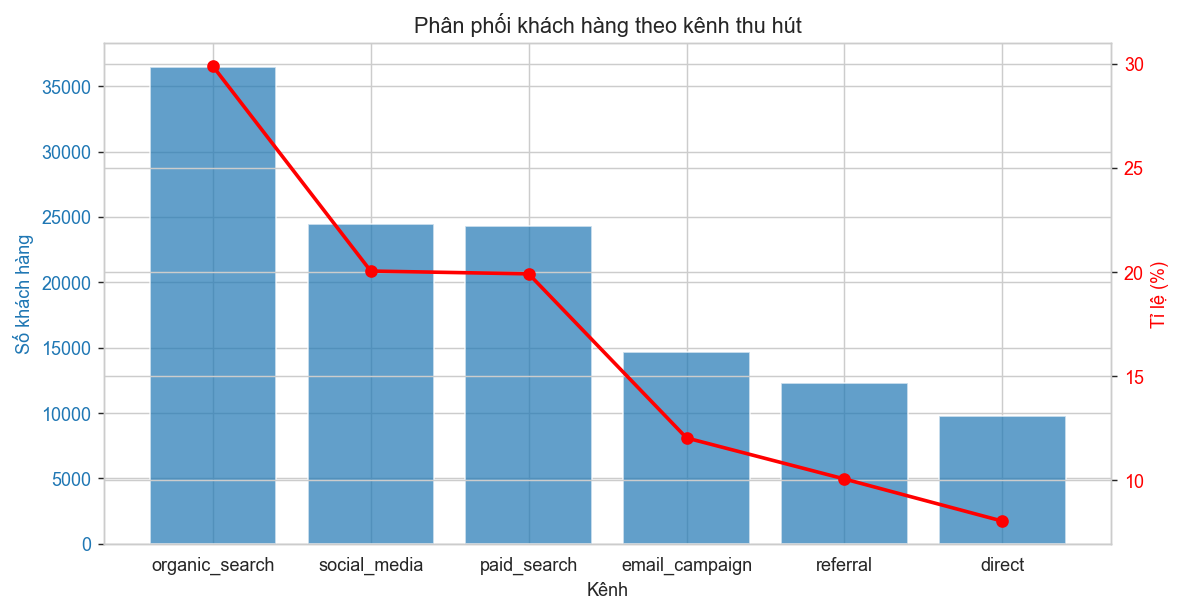

In [70]:
print_customer_distribution_via_acquistion_channel(customers)

In [71]:
def print_age_group_per_gender(df):
  ct_age_gender = pd.crosstab(df['age_group'], df['gender'], normalize='index')
  print("\n== Tỉ lệ giới tính trong mỗi nhóm tuổi ==")
  print((ct_age_gender * 100).round(2))

  # Biểu đồ stacked bar
  ct_age_gender.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10,6))
  plt.title('Phân bố giới tính theo nhóm tuổi')
  plt.ylabel('Tỉ lệ')
  plt.xticks(rotation=0)
  plt.legend(title='Gender')
  plt.show()

  # Heatmap đếm
  ct_count = pd.crosstab(df['age_group'], df['gender'])
  sns.heatmap(ct_count, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
  plt.title('Ma trận đếm Age Group × Gender')
  plt.show()


== Tỉ lệ giới tính trong mỗi nhóm tuổi ==
gender     Female   Male  Non-binary
age_group                           
18-24       49.35  46.77        3.88
25-34       48.94  47.21        3.85
35-44       48.57  47.40        4.03
45-54       48.91  46.95        4.14
55+         49.10  46.99        3.91


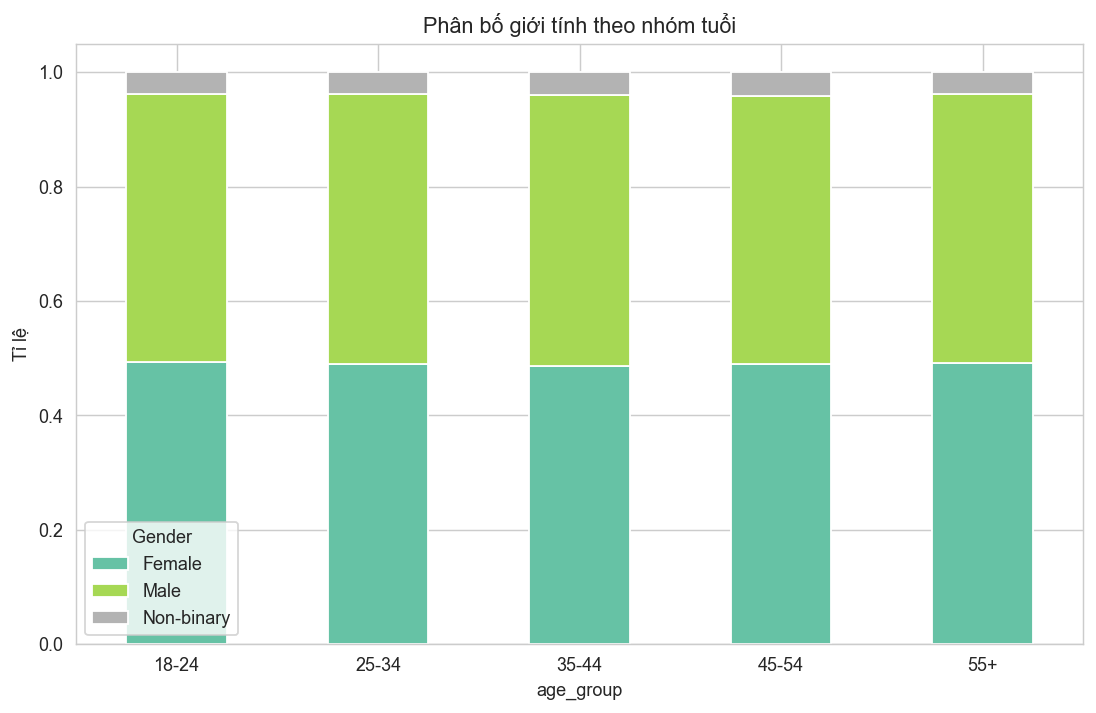

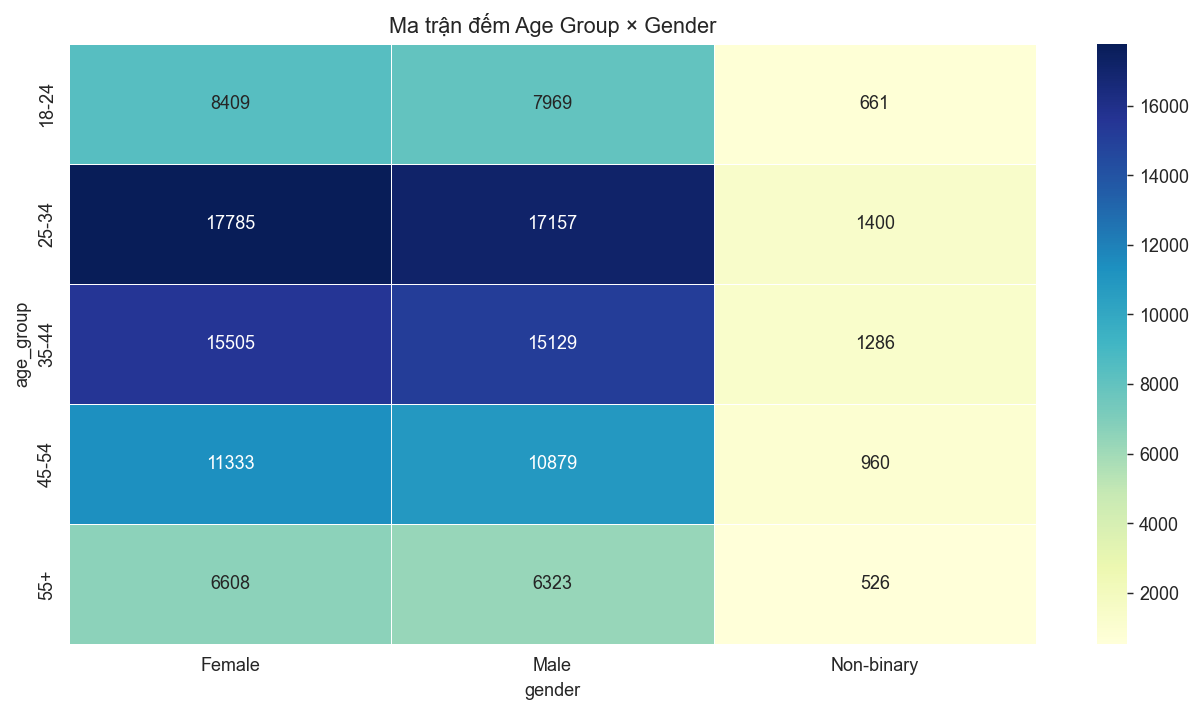

In [72]:
print_age_group_per_gender(customers)

In [73]:
def print_customer_count_per_region(df):
  # Top 10 thành phố
  top10 = df['city'].value_counts().head(10)
  print("\n== Top 10 thành phố ==")
  print(top10)

  plt.figure(figsize=(10,5))
  sns.barplot(x=top10.index, y=top10.values, palette='viridis')
  plt.title('Top 10 thành phố có nhiều khách hàng nhất')
  plt.xticks(rotation=45)
  plt.ylabel('Số khách hàng')
  plt.show()

  # Phân bố vùng theo tỉ lệ cho trước
  reg_counts = df['region'].value_counts()
  reg_pct = df['region'].value_counts(normalize=True) * 100
  print("\n== Phân bố vùng ==")
  print(pd.DataFrame({'count': reg_counts, 'percentage': reg_pct.round(2)}))

  plt.figure(figsize=(8,8))
  plt.pie(reg_counts, labels=reg_counts.index, autopct='%1.1f%%', startangle=140, 
          colors=sns.color_palette('pastel')[0:len(reg_counts)])
  plt.title('Thị phần khách hàng theo vùng')
  plt.show()


== Top 10 thành phố ==
city
Cam Pha        4398
Thai Nguyen    4347
Phu Ly         4243
Hanoi          4240
Ha Long        4236
Bac Ninh       4172
Hai Phong      4170
Nam Dinh       4169
Bac Giang      4160
Ninh Binh      4081
Name: count, dtype: int64


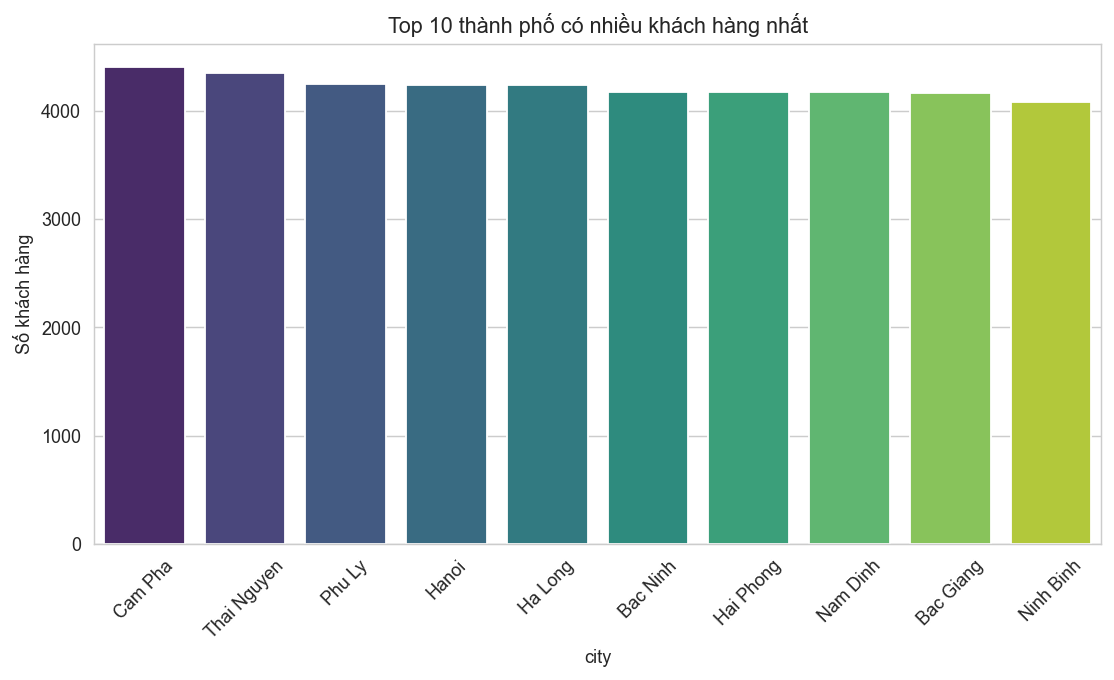


== Phân bố vùng ==
              count  percentage
region                         
Bac Bo        58178       47.71
Nam Trung Bo  32817       26.91
Tay Nam Bo    12020        9.86
Bac Trung Bo   7631        6.26
Tay Nguyen     7501        6.15
Dong Nam Bo    3783        3.10


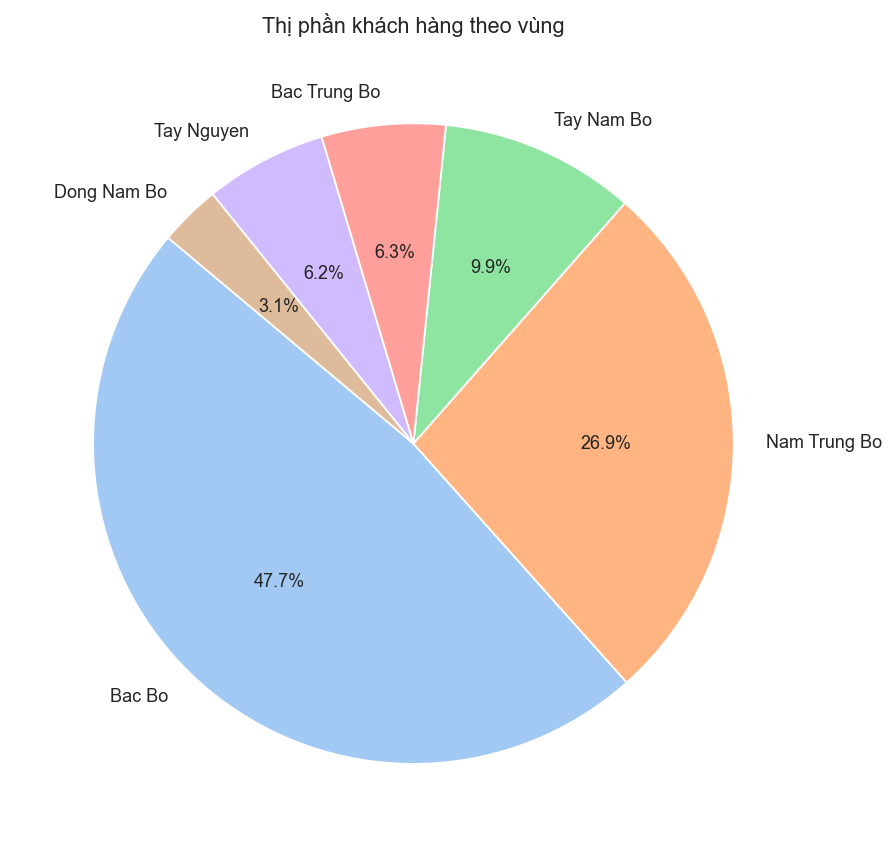

In [74]:
print_customer_count_per_region(customers)

In [87]:
def customer_sign_up_per_month(df):
  # Số khách đăng ký theo tháng
  monthly_signups = df.set_index('signup_date').resample('ME')['customer_id'].count()
  print("\n== Số lượng khách tham gia theo từng tháng ==")
  print(monthly_signups.head(10))
  print("\n== Trung bình đăng ký theo tháng ==")
  print(monthly_signups.describe())

  plt.figure(figsize=(14,5))
  plt.plot(monthly_signups.index, monthly_signups.values, marker='o', linestyle='-', markersize=3)
  plt.title('Số lượng khách hàng mới theo tháng')
  plt.xlabel('Thời gian')
  plt.ylabel('Số khách')
  plt.grid(True)
  plt.show()


== Số lượng khách tham gia theo từng tháng ==
signup_date
2012-01-31      2
2012-02-29     21
2012-03-31     28
2012-04-30     40
2012-05-31     67
2012-06-30     73
2012-07-31     90
2012-08-31     96
2012-09-30    118
2012-10-31    146
Freq: ME, Name: customer_id, dtype: int64

== Trung bình đăng ký theo tháng ==
count     132.000000
mean      923.712121
std       537.257931
min         2.000000
25%       469.000000
50%       916.500000
75%      1379.000000
max      1883.000000
Name: customer_id, dtype: float64


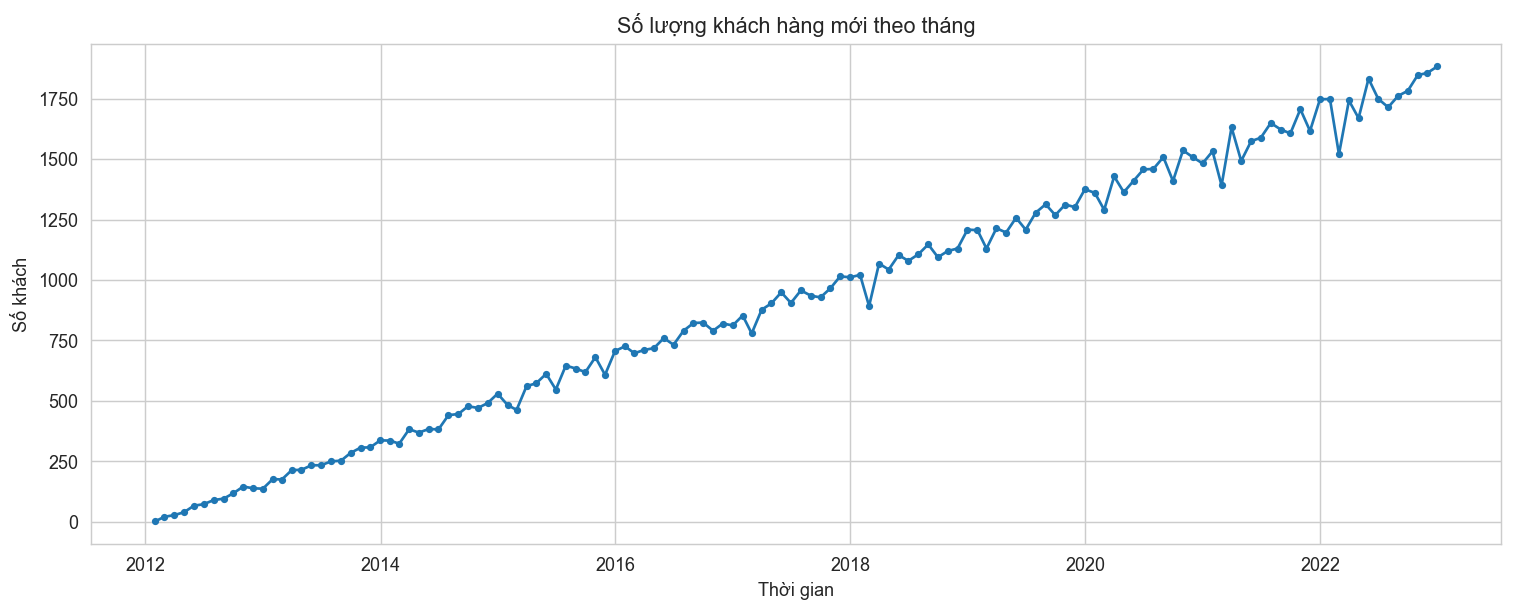

In [88]:
customer_sign_up_per_month(customers)

In [95]:
def customer_count_per_quarter(df):
  # Tạo cột quý dạng '2012-Q1' để nhóm
  df['year_quarter'] = df['signup_date'].dt.to_period('Q')
  print(df['year_quarter'])
  quarterly_counts = df.groupby('year_quarter')['customer_id'].count()
  print("\n== Thống kê số khách hàng mới mỗi quý (toàn bộ giai đoạn) ==")
  print(f"\n{quarterly_counts.head(10)}")
  stats = {
      'mean': quarterly_counts.mean(),
      'median': quarterly_counts.median(),
      'std': quarterly_counts.std(),
      'skewness': skew(quarterly_counts),
      'kurtosis': kurtosis(quarterly_counts)
  }
  print(pd.Series(stats).round(2))

  # Biểu đồ phân phối số khách/ quý
  fig, axes = plt.subplots(1, 2, figsize=(14,5))
  # Histogram (density)
  sns.histplot(quarterly_counts, kde=True, ax=axes[0], bins=20)
  axes[0].set_title('Phân phối số khách hàng mới mỗi quý')
  axes[0].set_xlabel('Số khách/ quý')

  # Boxplot
  sns.boxplot(x=quarterly_counts, ax=axes[1])
  axes[1].set_title('Boxplot số khách hàng mới mỗi quý')
  axes[1].set_xlabel('Số khách/ quý')

  plt.tight_layout()
  plt.show()

  quarterly_counts.index = quarterly_counts.index.to_timestamp()

  plt.figure(figsize=(12,5))
  plt.plot(quarterly_counts.index, quarterly_counts.values)
  plt.title("Số lượng khách hàng đăng ký theo quý (Trend)")
  plt.xlabel("Thời gian")
  plt.ylabel("Số khách")
  plt.show()

0         2021Q4
1         2013Q4
2         2018Q3
3         2017Q4
4         2022Q3
           ...  
121925    2016Q1
121926    2021Q2
121927    2017Q1
121928    2018Q4
121929    2018Q3
Name: year_quarter, Length: 121930, dtype: period[Q-DEC]

== Thống kê số khách hàng mới mỗi quý (toàn bộ giai đoạn) ==

year_quarter
2012Q1      51
2012Q2     180
2012Q3     304
2012Q4     422
2013Q1     566
2013Q2     683
2013Q3     788
2013Q4     952
2014Q1    1042
2014Q2    1135
Freq: Q-DEC, Name: customer_id, dtype: int64
mean        2771.14
median      2788.50
std         1620.28
skewness      -0.00
kurtosis      -1.18
dtype: float64


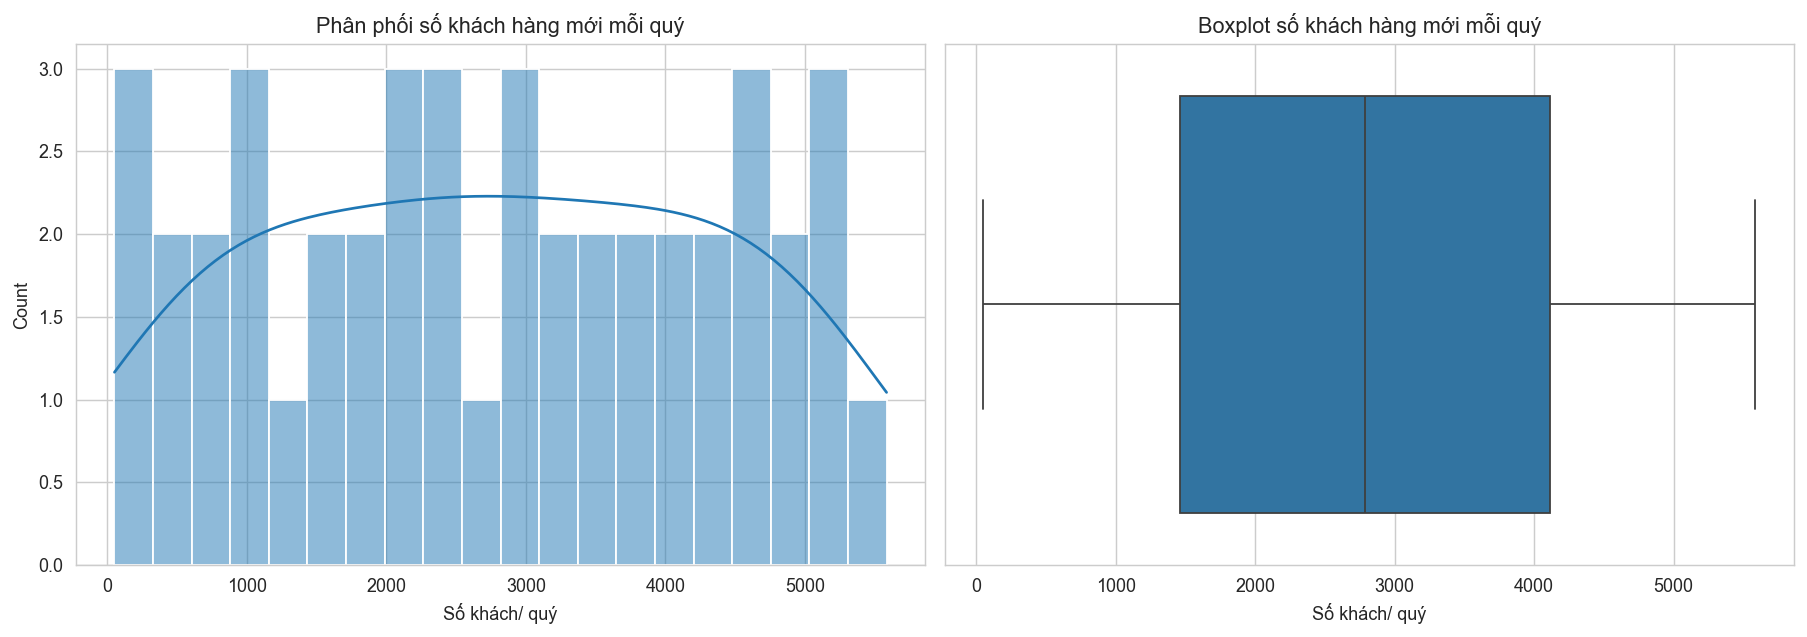

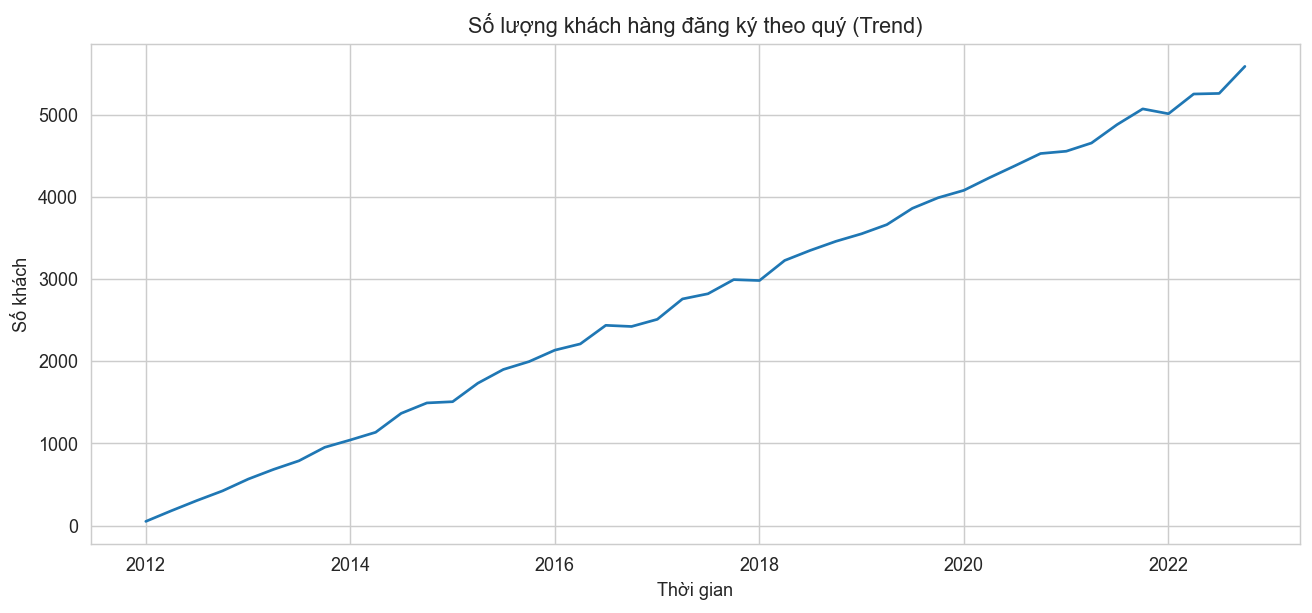

In [96]:
customer_count_per_quarter(customers)

In [138]:
def plot_bienial_analysis(df):
  df['signup_quarter'] = df['signup_date'].dt.to_period('Q').astype(str)

  # Tạo khối 2 năm: 2012-2013, 2014-2015, ..., 2020-2021
  df['biennial'] = pd.cut(df['signup_year'], 
                          bins=[2012,2014,2016,2018,2020,2022], 
                          labels=['2012-2013','2014-2015','2016-2017','2018-2019','2020-2021'],
                          right=True, include_lowest=True)
  # Lưu ý: 2022 chỉ mình nó, có thể bỏ hoặc gộp. Ở đây ta bỏ 2022 để giữ 5 khối tròn.
  df_biennial = df[df['biennial'].notna()]  # loại bỏ nếu có NaN

  biennial_quarterly = df_biennial.groupby(['biennial', 'signup_quarter'])['customer_id'].count().unstack()
  print("\n== Trung bình khách mới theo quý trong mỗi khối 2 năm ==")
  print(biennial_quarterly.mean(axis=1).round(2))

  biennial_quarterly.plot(kind='bar', figsize=(12,5), colormap='Set2')
  plt.title('Số khách hàng mới theo quý, nhóm 2 năm một')
  plt.ylabel('Số khách')
  plt.xticks(rotation=45)
  plt.legend(title='Quarter')
  plt.show()


== Trung bình khách mới theo quý trong mỗi khối 2 năm ==
biennial
2012-2013     748.33
2014-2015    2041.88
2016-2017    3011.12
2018-2019    4033.62
2020-2021    5032.12
dtype: float64


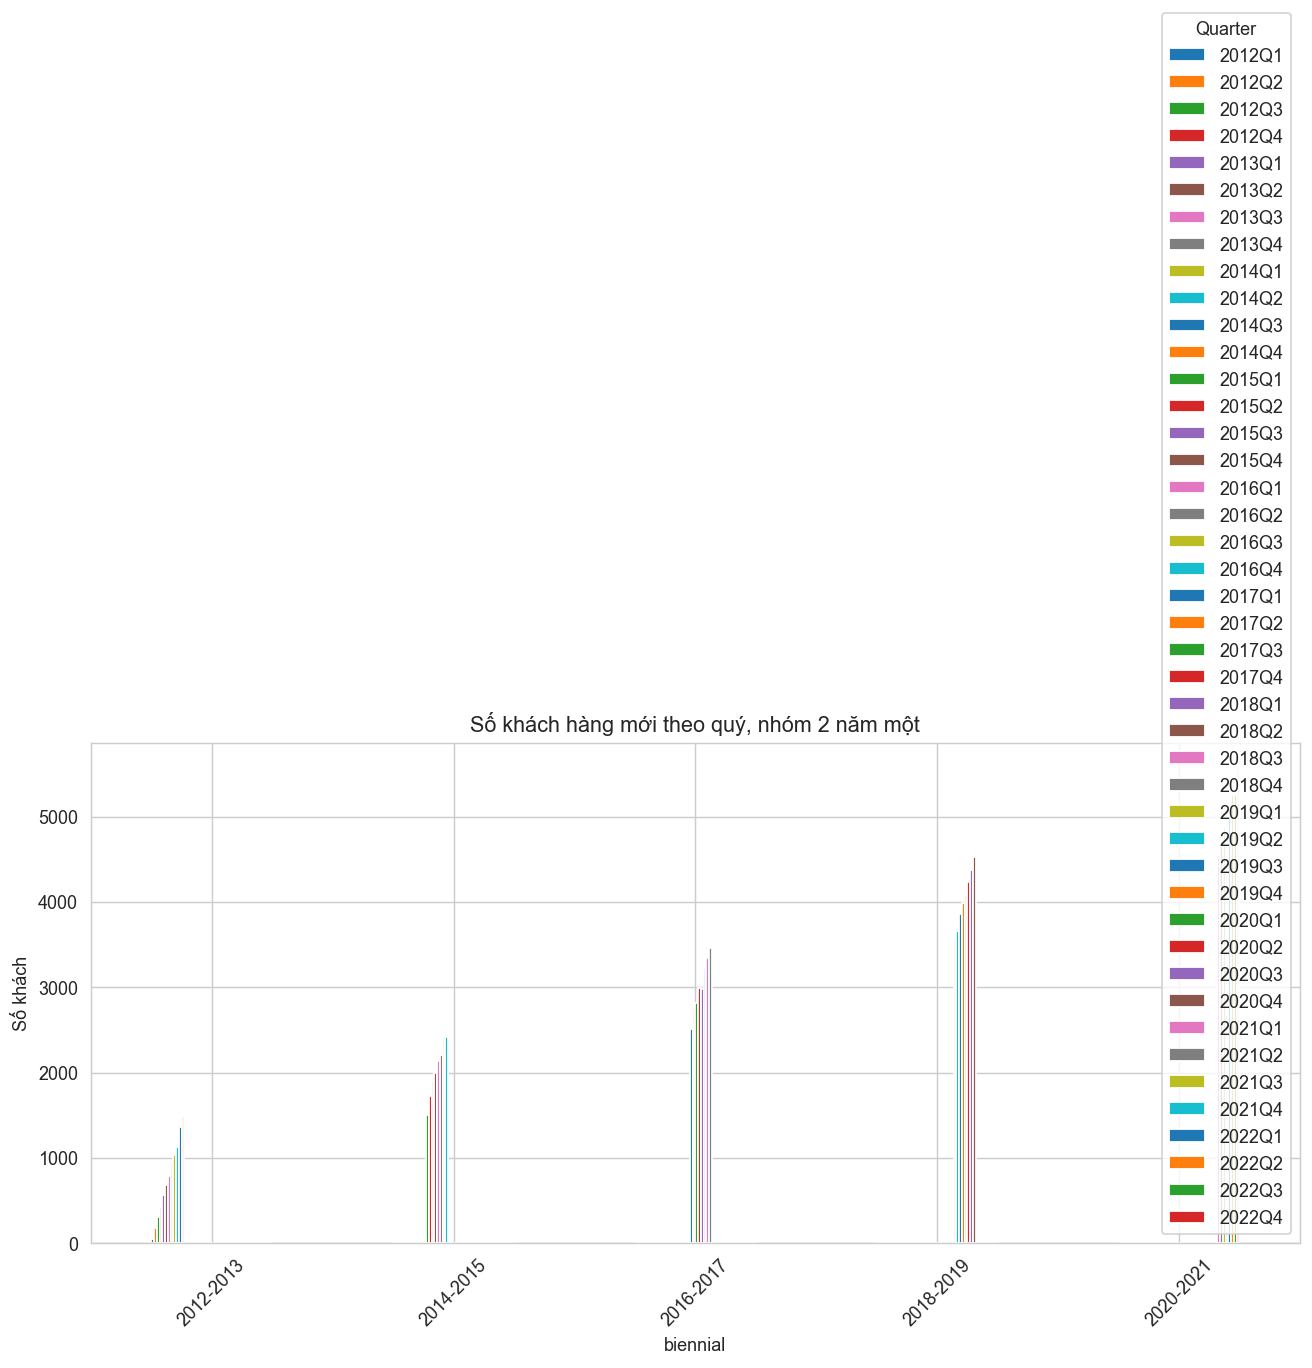

In [137]:
plot_bienial_analysis(customers)

In [128]:
def compute_qoq_growth(df):
    quarterly_counts = df.groupby('year_quarter')['customer_id'].count()
    
    growth = quarterly_counts.pct_change() * 100
    return growth

def plot_qoq_growth(df):
    growth = compute_qoq_growth(df)
    plt.figure(figsize=(12,5))
    growth.plot()
    plt.title("QoQ Growth (%)")
    plt.axhline(0, linestyle='--')
    plt.show()

def compute_yoy_growth(df):
    quarterly_counts = df.groupby('signup_year')['customer_id'].count()
    
    growth = quarterly_counts.pct_change() * 100
    return growth

def plot_yoy_growth(df):
    growth = compute_yoy_growth(df)
    plt.figure(figsize=(12,5))
    growth.plot()
    plt.title("YoY Growth (%)")
    plt.axhline(0, linestyle='--')
    plt.show()

def compute_mom_growth(df):
    quarterly_counts = df.groupby('signup_month')['customer_id'].count()
    
    growth = quarterly_counts.pct_change() * 100
    return growth

def plot_mom_growth(df):
    growth = compute_mom_growth(df)
    plt.figure(figsize=(12,5))
    growth.plot()
    plt.title("MoM Growth (%)")
    plt.axhline(0, linestyle='--')
    plt.show()

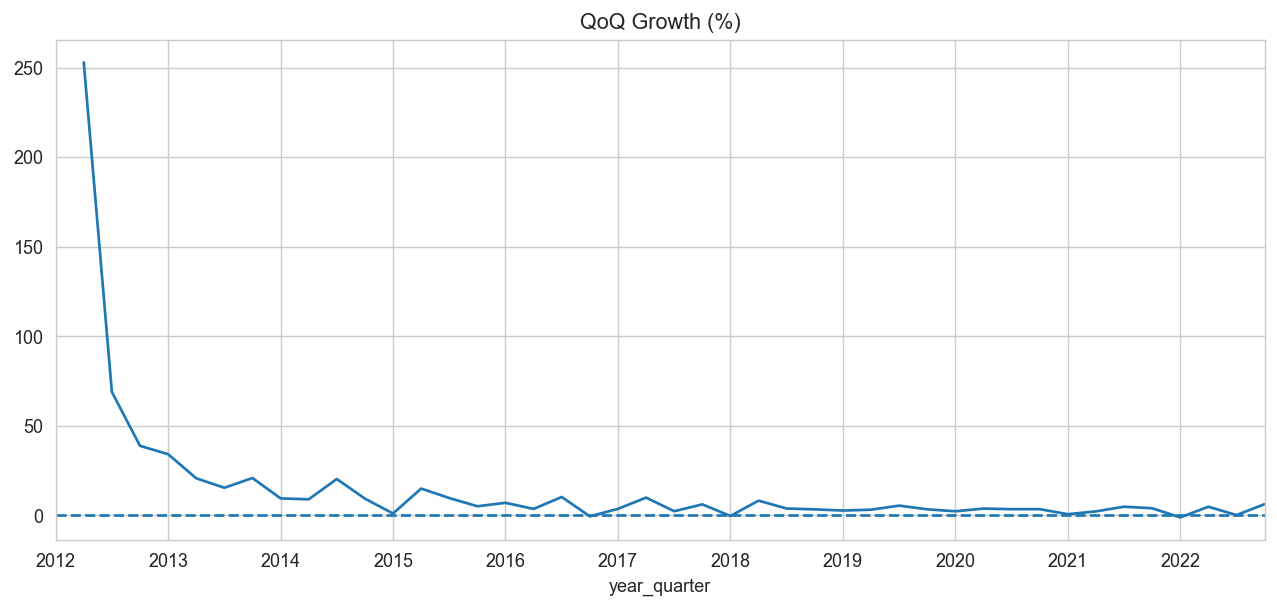

In [100]:
plot_qoq_growth(customers)

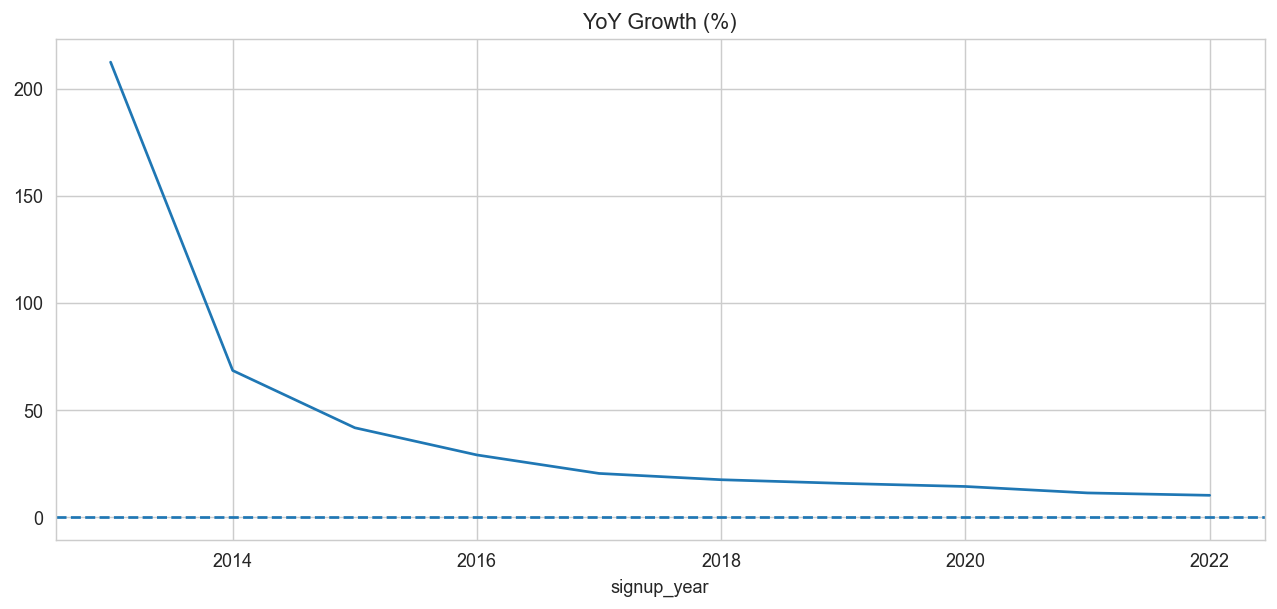

In [125]:
plot_yoy_growth(customers)

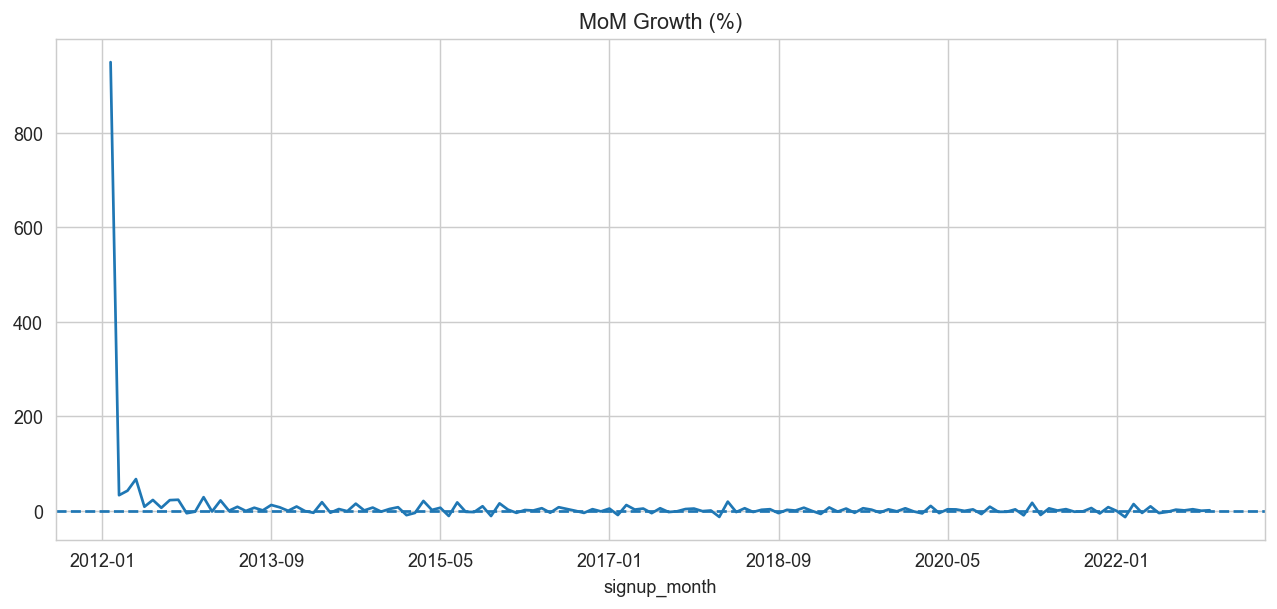

In [129]:
plot_mom_growth(customers)

In [101]:
def detect_spikes(df, threshold=2):
    quarterly_counts = df.groupby('year_quarter')['customer_id'].count()
    z_scores = (quarterly_counts - quarterly_counts.mean()) / quarterly_counts.std()
    spikes = quarterly_counts[np.abs(z_scores) > threshold]
    return spikes

In [102]:
detect_spikes(customers)

Series([], Freq: Q-DEC, Name: customer_id, dtype: int64)

In [119]:
from statsmodels.tsa.seasonal import seasonal_decompose

def seasonal_analysis(df, value_col='customer_id', title="Phân tích mùa vụ dữ liệu theo quý"):
    """
    Phân tích thành phần xu hướng - mùa vụ - ngẫu nhiên của chuỗi thời gian theo quý.
    """
    if 'year_quarter' not in df.columns:
        raise ValueError("DataFrame phải có cột 'year_quarter'")

    # Tạo chuỗi thời gian
    if value_col == 'customer_id':
        quarterly_counts = df.groupby('year_quarter')['customer_id'].count()
    else:
        quarterly_counts = df.groupby('year_quarter')[value_col].sum()

    # Chuyển sang PeriodIndex rồi thành Timestamp để seasonal_decompose hoạt động tốt
    ts = quarterly_counts.copy()
    ts.index = pd.PeriodIndex(ts.index, freq='Q').to_timestamp()

    # Phân tích mùa vụ (period=4 vì là dữ liệu quý)
    result = seasonal_decompose(ts, model='additive', period=4, extrapolate_trend='freq')

    # Vẽ biểu đồ
    fig = result.plot()
    fig.set_size_inches(14, 10)
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # === Phân tích bổ sung ===
    print("=== PHÂN TÍCH MÙA VỤ ===")
    print(f"Trend mạnh nhất: {result.trend.max():.0f} (tại {result.trend.idxmax()})")
    print(f"Seasonal mạnh nhất: {result.seasonal.max():.2f} | Yếu nhất: {result.seasonal.min():.2f}")
    
    # Tính % đóng góp của seasonal
    seasonal_strength = (result.seasonal.std() / ts.std()) * 100
    print(f"Độ mạnh của yếu tố mùa vụ: {seasonal_strength:.1f}%")

    return result

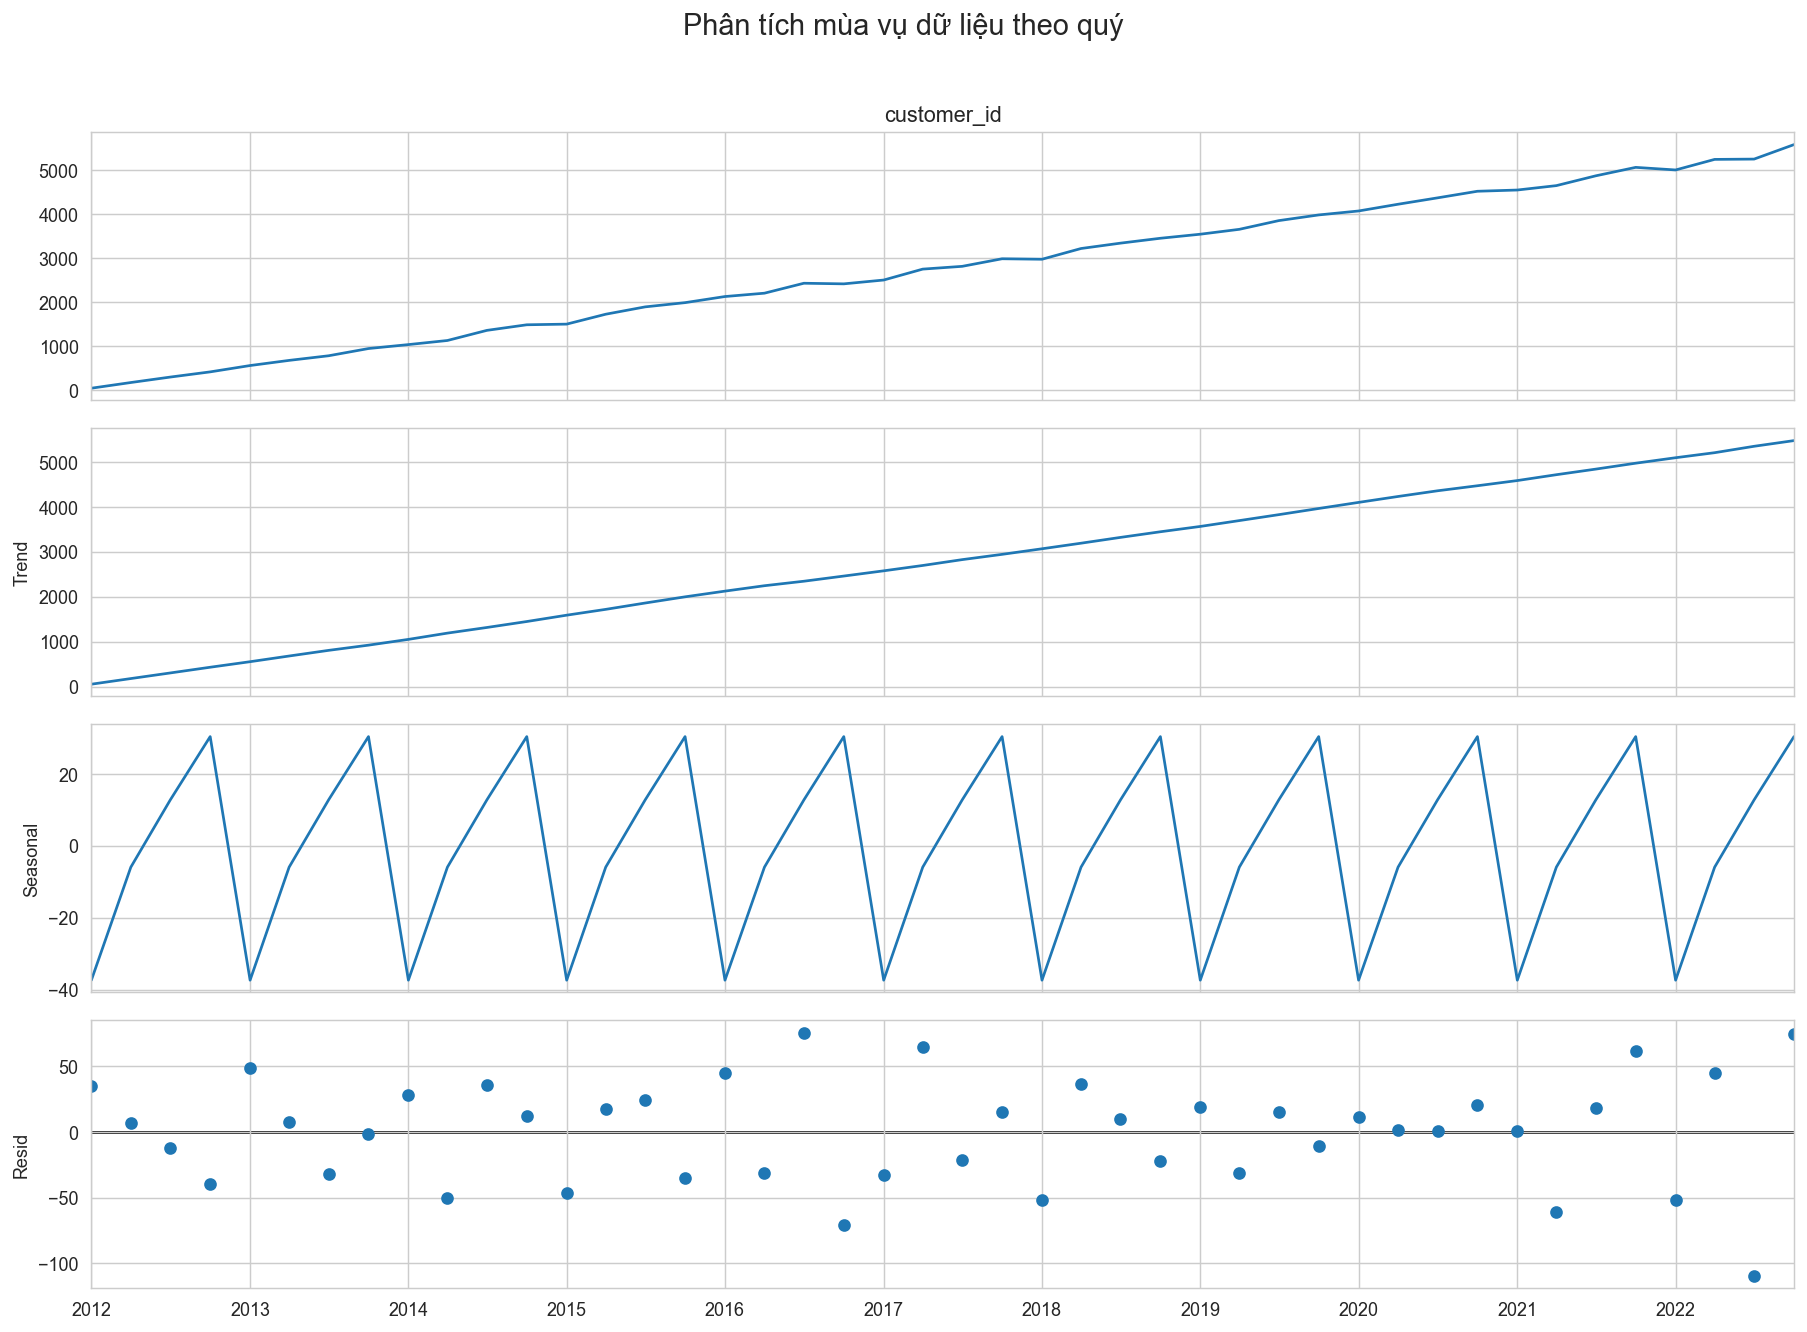

=== PHÂN TÍCH MÙA VỤ ===
Trend mạnh nhất: 5481 (tại 2022-10-01 00:00:00)
Seasonal mạnh nhất: 30.42 | Yếu nhất: -37.34
Độ mạnh của yếu tố mùa vụ: 1.6%


In [120]:
seasonal_analysis(customers)

In [117]:
def cohort_by_quarter(df, value_col=None, title="Tỷ lệ phân bổ kênh theo quý"):
    """
    Phân tích cohort theo quý và acquisition channel.
    
    Parameters:
        df: DataFrame phải có cột 'year_quarter' và 'acquisition_channel'
        value_col: Nếu muốn đếm theo một cột giá trị khác (ví dụ: 'revenue'), truyền tên cột vào.
    """
    if 'year_quarter' not in df.columns or 'acquisition_channel' not in df.columns:
        raise ValueError("DataFrame phải có cột 'year_quarter' và 'acquisition_channel'")

    # Nếu không truyền value_col thì đếm số lượng (size)
    if value_col is None or value_col not in df.columns:
        cohort = df.groupby(['year_quarter', 'acquisition_channel']).size().unstack(fill_value=0)
    else:
        cohort = df.groupby(['year_quarter', 'acquisition_channel'])[value_col].sum().unstack(fill_value=0)

    # Tính tỷ lệ % của từng kênh trong quý đó
    cohort_ratio = cohort.div(cohort.sum(axis=1), axis=0) * 100   # nhân 100 để ra %

    # === Vẽ biểu đồ ===
    plt.figure(figsize=(14, 7))
    cohort_ratio.plot(kind='area', stacked=True, alpha=0.85, colormap='tab20')
    plt.title(title, fontsize=16, pad=20)
    plt.xlabel("Quý")
    plt.ylabel("Tỷ lệ (%)")
    plt.legend(title="Acquisition Channel", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # === Phân tích bổ sung ===
    print("=== PHÂN TÍCH COHORT THEO QUÝ ===")
    print(f"Tổng số quý: {len(cohort_ratio)}")
    print("\nTỷ lệ trung bình của từng kênh qua các quý:")
    print(cohort_ratio.mean().round(2).sort_values(ascending=False))
    
    print("\nKênh có biến động mạnh nhất (std cao nhất):")
    print(cohort_ratio.std().round(2).sort_values(ascending=False))

    return cohort_ratio

<Figure size 1820x910 with 0 Axes>

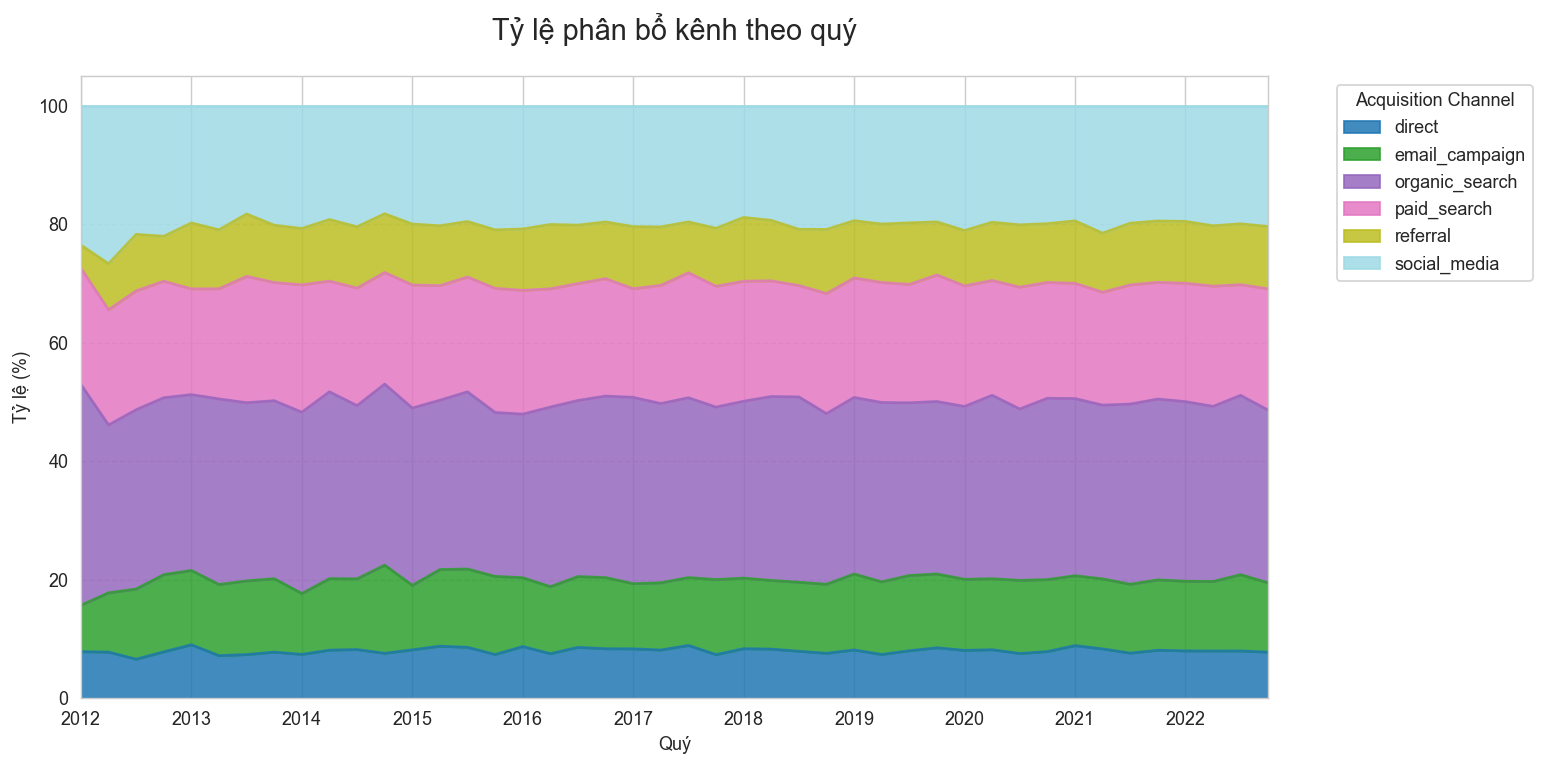

=== PHÂN TÍCH COHORT THEO QUÝ ===
Tổng số quý: 44

Tỷ lệ trung bình của từng kênh qua các quý:
acquisition_channel
organic_search    30.06
social_media      20.32
paid_search       19.87
email_campaign    11.94
referral           9.81
direct             7.99
dtype: float64

Kênh có biến động mạnh nhất (std cao nhất):
acquisition_channel
organic_search    1.44
social_media      1.36
referral          1.15
email_campaign    1.02
paid_search       0.82
direct            0.51
dtype: float64


acquisition_channel,direct,email_campaign,organic_search,paid_search,referral,social_media
year_quarter,,,,,,
2012Q1,7.843137,7.843137,37.254902,19.607843,3.921569,23.529412
2012Q2,7.777778,10.000000,28.333333,19.444444,7.777778,26.666667
2012Q3,6.578947,11.842105,30.263158,20.065789,9.539474,21.710526
2012Q4,7.819905,13.033175,29.857820,19.668246,7.582938,22.037915
2013Q1,9.010601,12.544170,29.681979,17.844523,11.130742,19.787986
2013Q2,7.174231,12.005857,31.332357,18.594436,9.956076,20.937042
2013Q3,7.360406,12.436548,30.076142,21.319797,10.532995,18.274112
2013Q4,7.773109,12.394958,30.042017,19.957983,9.663866,20.168067
2014Q1,7.389635,10.268714,30.614203,21.497121,9.500960,20.729367


In [118]:
cohort_by_quarter(customers)

In [121]:
def detect_spikes(df, threshold=2.5, value_col='customer_id'):
    """
    Phát hiện các quý có tăng/giảm bất thường (spike) bằng Z-score.
    
    Parameters:
        threshold: ngưỡng Z-score (thường dùng 2.5 hoặc 3.0)
    """
    if 'year_quarter' not in df.columns:
        raise ValueError("DataFrame phải có cột 'year_quarter'")

    # Tạo chuỗi thời gian
    if value_col == 'customer_id':
        quarterly_counts = df.groupby('year_quarter')['customer_id'].count()
    else:
        quarterly_counts = df.groupby('year_quarter')[value_col].sum()

    # Tính Z-score
    mean = quarterly_counts.mean()
    std = quarterly_counts.std()
    z_scores = (quarterly_counts - mean) / std

    # Phát hiện spike
    spikes = quarterly_counts[np.abs(z_scores) > threshold].copy()
    spikes_df = pd.DataFrame({
        'count': spikes,
        'z_score': z_scores[spikes.index],
        'deviation_%': ((spikes - mean) / mean * 100).round(1)
    })

    print(f"=== PHÁT HIỆN SPIKE (threshold = {threshold}) ===")
    print(f"Trung bình quý: {mean:,.0f} | Độ lệch chuẩn: {std:,.0f}")
    if len(spikes_df) > 0:
        print(f"\nTìm thấy {len(spikes_df)} quý bất thường:")
        print(spikes_df.round(2))
    else:
        print("Không tìm thấy spike nào vượt ngưỡng.")

    # Vẽ biểu đồ để dễ quan sát
    plt.figure(figsize=(14, 6))
    plt.plot(quarterly_counts.index.astype(str), quarterly_counts, marker='o', label='Số lượng')
    plt.scatter(spikes.index.astype(str), spikes, color='red', s=100, zorder=5, label=f'Spike (Z > {threshold})')
    plt.axhline(mean, color='green', linestyle='--', alpha=0.7, label='Mean')
    plt.title("Phát hiện Spike theo Quý", fontsize=15)
    plt.xlabel("Quý")
    plt.ylabel("Số lượng")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return spikes_df

=== PHÁT HIỆN SPIKE (threshold = 2.5) ===
Trung bình quý: 2,771 | Độ lệch chuẩn: 1,620
Không tìm thấy spike nào vượt ngưỡng.


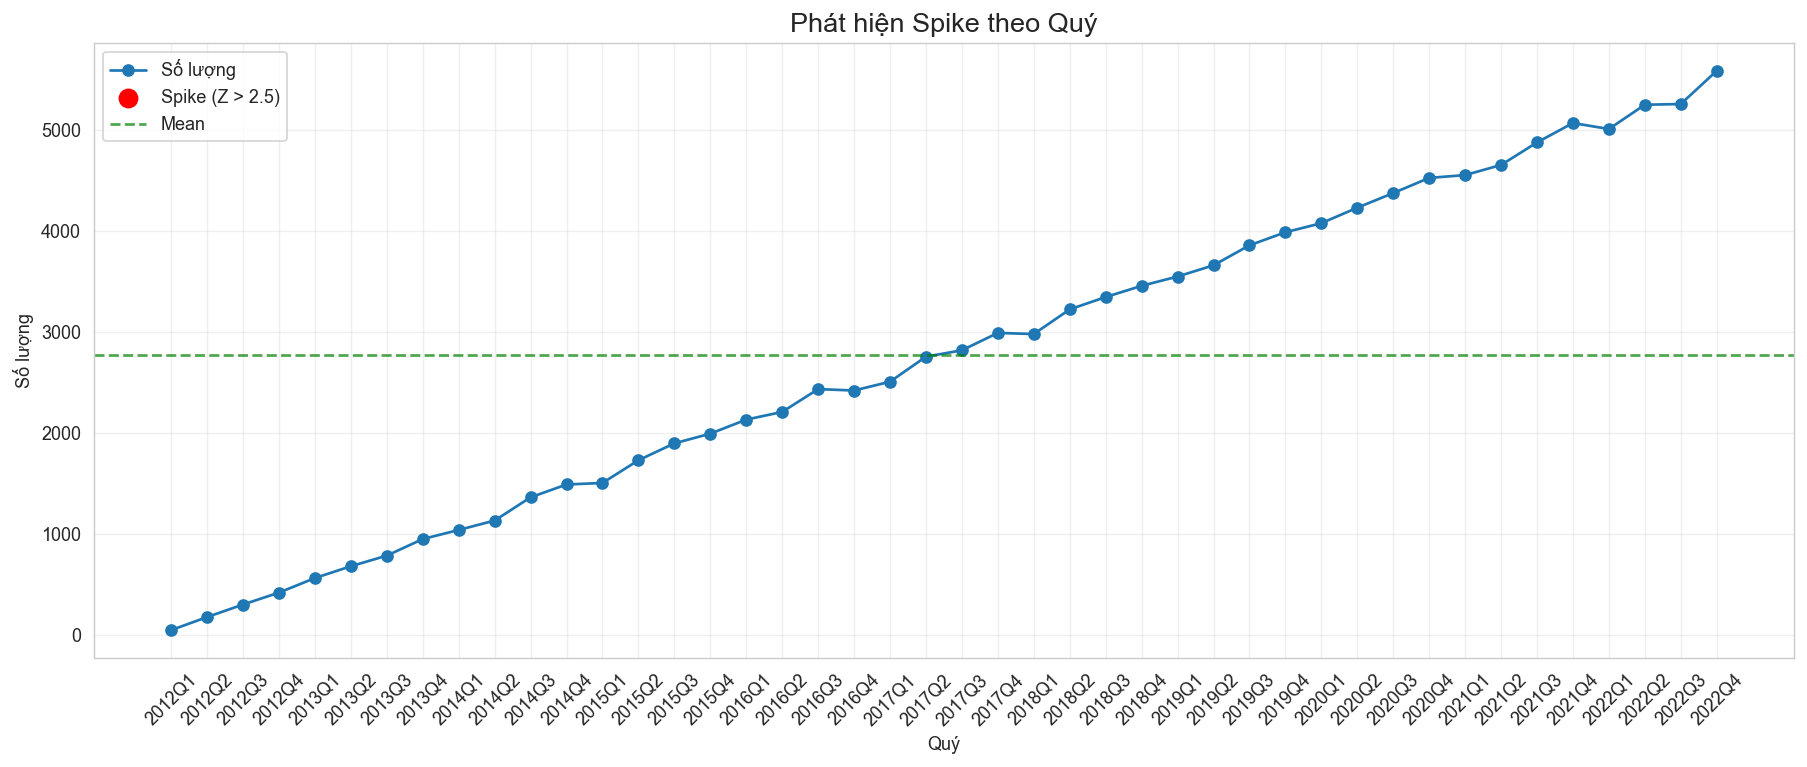

,count,z_score,deviation_%
year_quarter,,,


In [122]:
detect_spikes(customers)


CATEGORY vs SEGMENT DISTRIBUTION


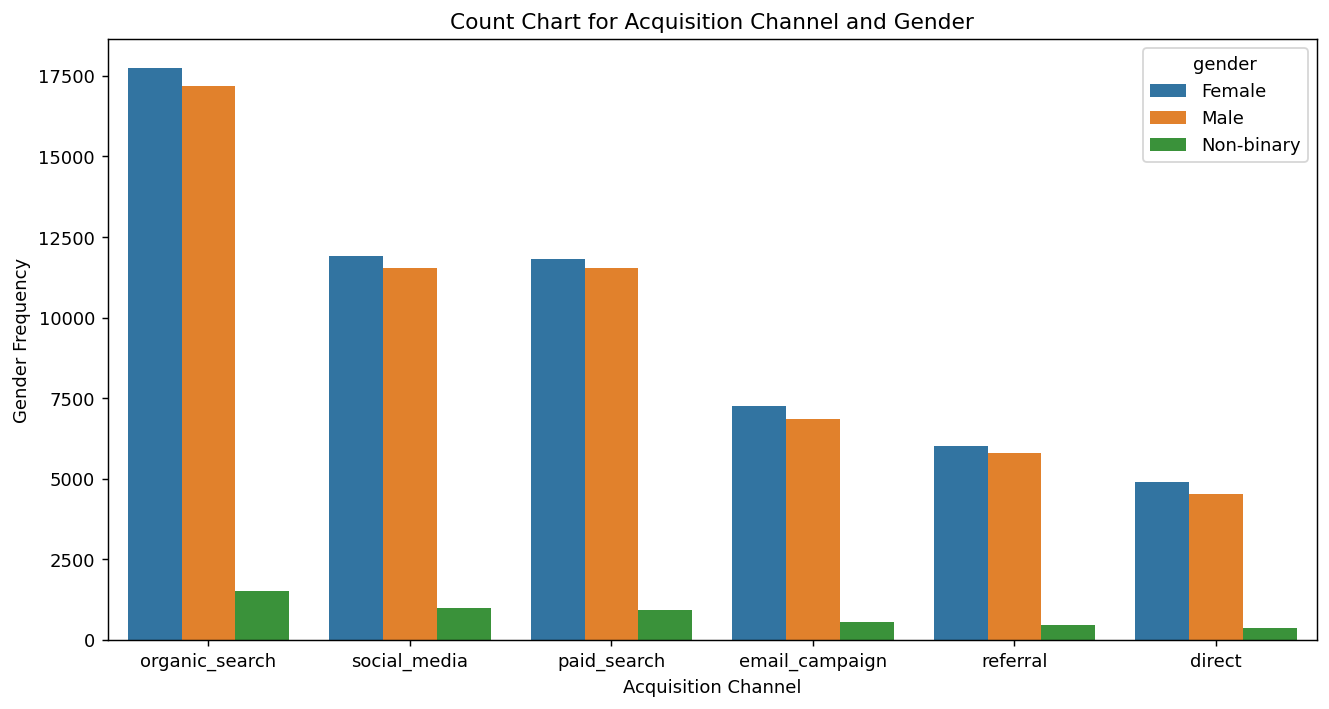

In [53]:
plot_gender_acquisition_channel(customers)

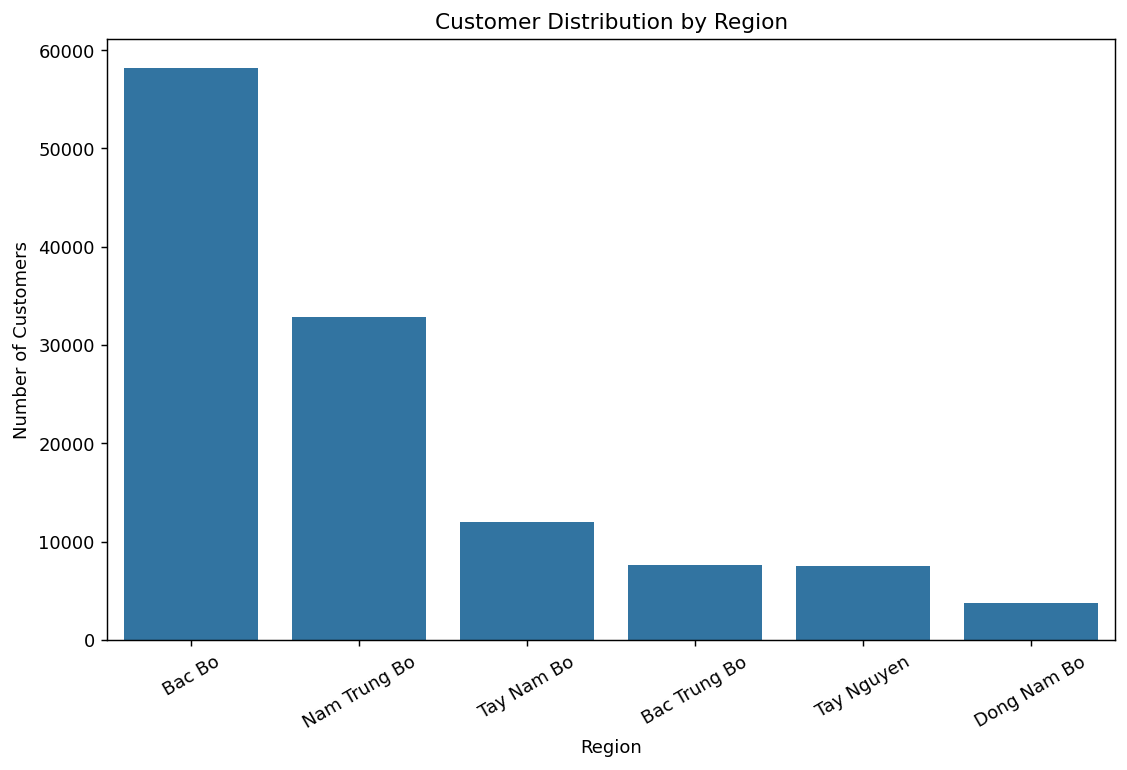


Distribution:
region
Bac Bo          0.477
Nam Trung Bo    0.269
Tay Nam Bo      0.099
Bac Trung Bo    0.063
Tay Nguyen      0.062
Dong Nam Bo     0.031
Name: proportion, dtype: float64


In [51]:
plot_customer_distribution_by_region(customers)

In [ ]:
chi_square_test(customers)

In [65]:
print(customers['region'])

0              Bac Bo
1              Bac Bo
2              Bac Bo
3              Bac Bo
4              Bac Bo
             ...     
121925    Dong Nam Bo
121926    Dong Nam Bo
121927    Dong Nam Bo
121928     Tay Nguyen
121929     Tay Nguyen
Name: region, Length: 121930, dtype: str


BẮT ĐẦU PHÂN TÍCH DỮ LIỆU KHÁCH HÀNG

1. PHÂN TÍCH ĐƠN BIẾN - CẤU TRÚC KHÁCH HÀNG

--- ACQUISITION CHANNEL ---
Số lượng và tỉ lệ khách hàng theo kênh:
                     Count  Percentage
acquisition_channel                   
organic_search       36450       29.89
social_media         24448       20.05
paid_search          24285       19.92
email_campaign       14674       12.03
referral             12270       10.06
direct                9803        8.04


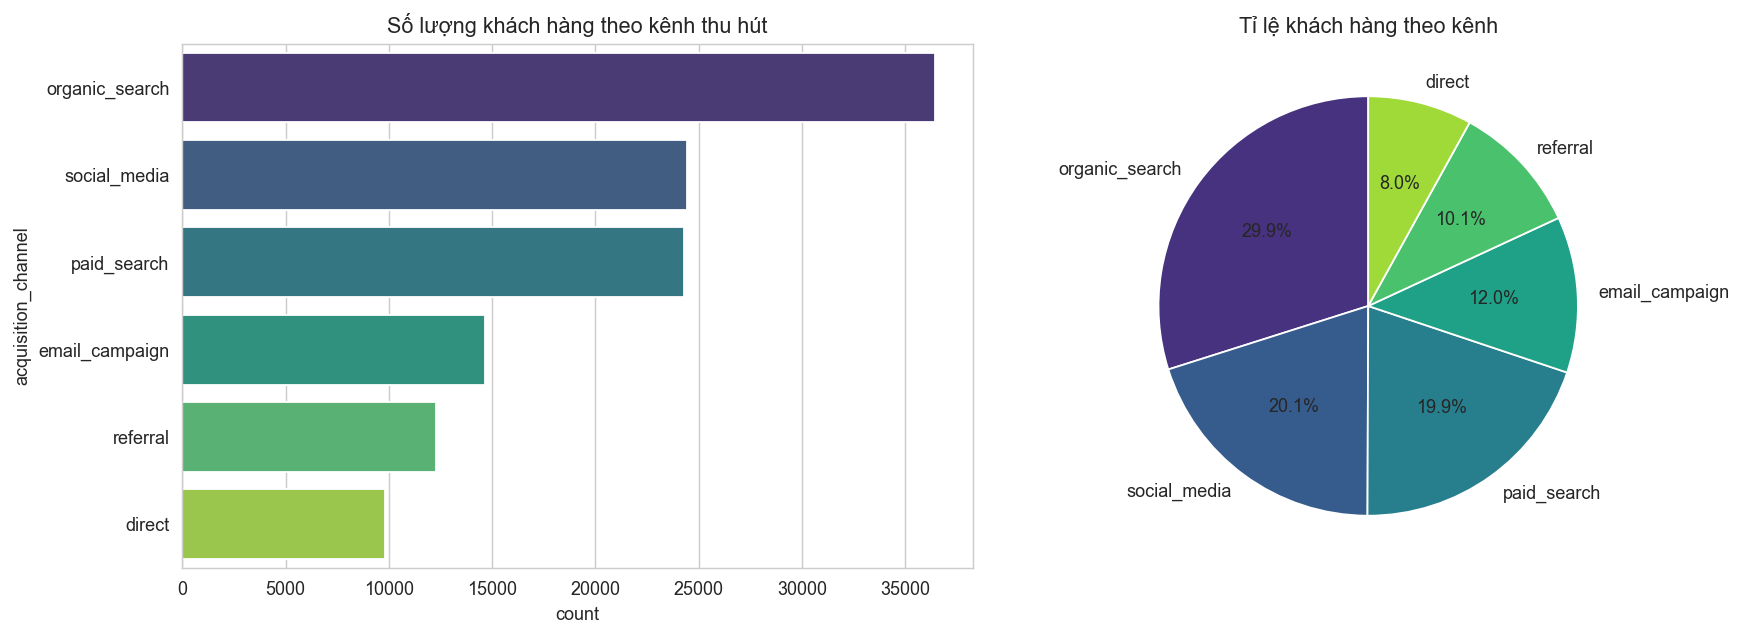

Insight: Top 3 kênh chiếm 69.9% tổng lượng khách.
Chỉ số đa dạng kênh (Entropy): 1.69
✅ Tín hiệu: Cơ cấu kênh thu hút khá lành mạnh, rủi ro dàn trải được kiểm soát.
Kiểm định Chi-square (phân phối đều): chi2=24615.38, p=0.0000 -> Không đồng đều

--- AGE GROUP & GENDER ---
Phân phối chung Age group vs Gender:
gender     Female   Male  Non-binary
age_group                           
18-24        8409   7969         661
25-34       17785  17157        1400
35-44       15505  15129        1286
45-54       11333  10879         960
55+          6608   6323         526

Tỉ lệ phần trăm theo dòng:
gender     Female  Male  Non-binary
age_group                          
18-24        49.4  46.8         3.9
25-34        48.9  47.2         3.9
35-44        48.6  47.4         4.0
45-54        48.9  46.9         4.1
55+          49.1  47.0         3.9

--- 1.2 NHÂN KHẨU HỌC: ĐỘ TRUNG THỰC CỦA DỮ LIỆU ---
Nhóm khách hàng nòng cốt: 25-34 (29.8%)


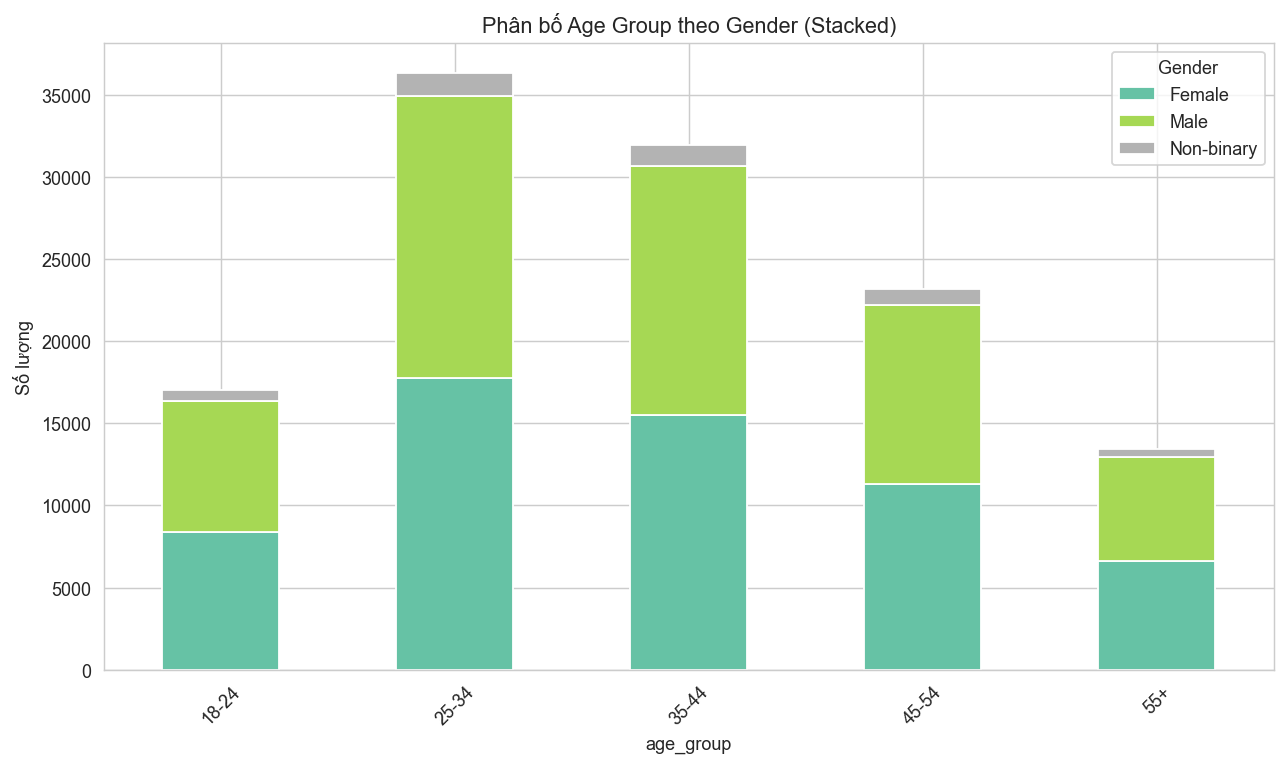

Nhóm tuổi phổ biến nhất: 25-34, Giới tính phổ biến nhất: Female


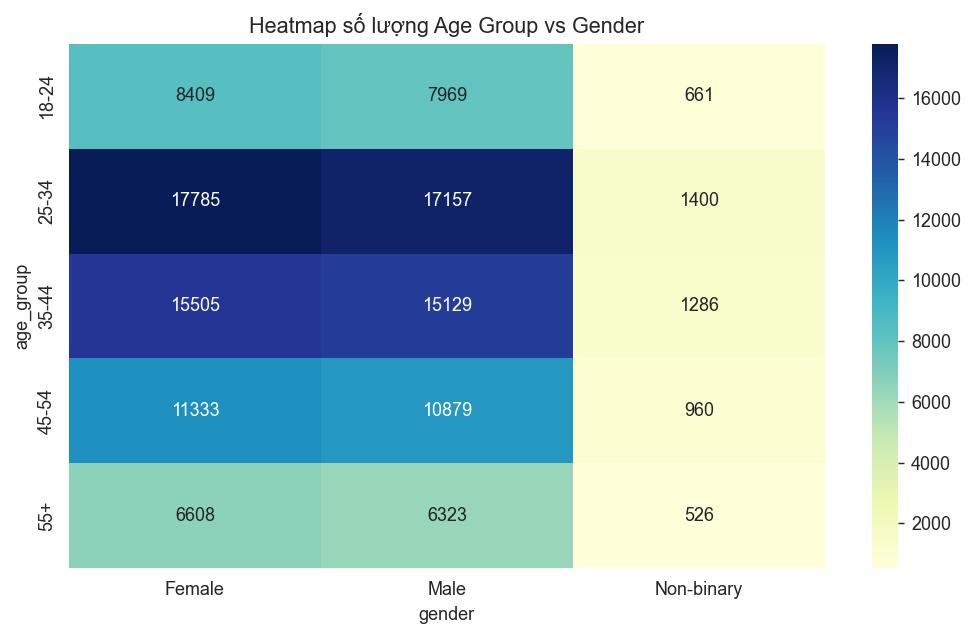


--- GEOGRAPHIC (CITY, ZIP) ---
Top 10 thành phố có nhiều khách hàng nhất:
city
Cam Pha        4398
Thai Nguyen    4347
Phu Ly         4243
Hanoi          4240
Ha Long        4236
Bac Ninh       4172
Hai Phong      4170
Nam Dinh       4169
Bac Giang      4160
Ninh Binh      4081
Name: count, dtype: int64


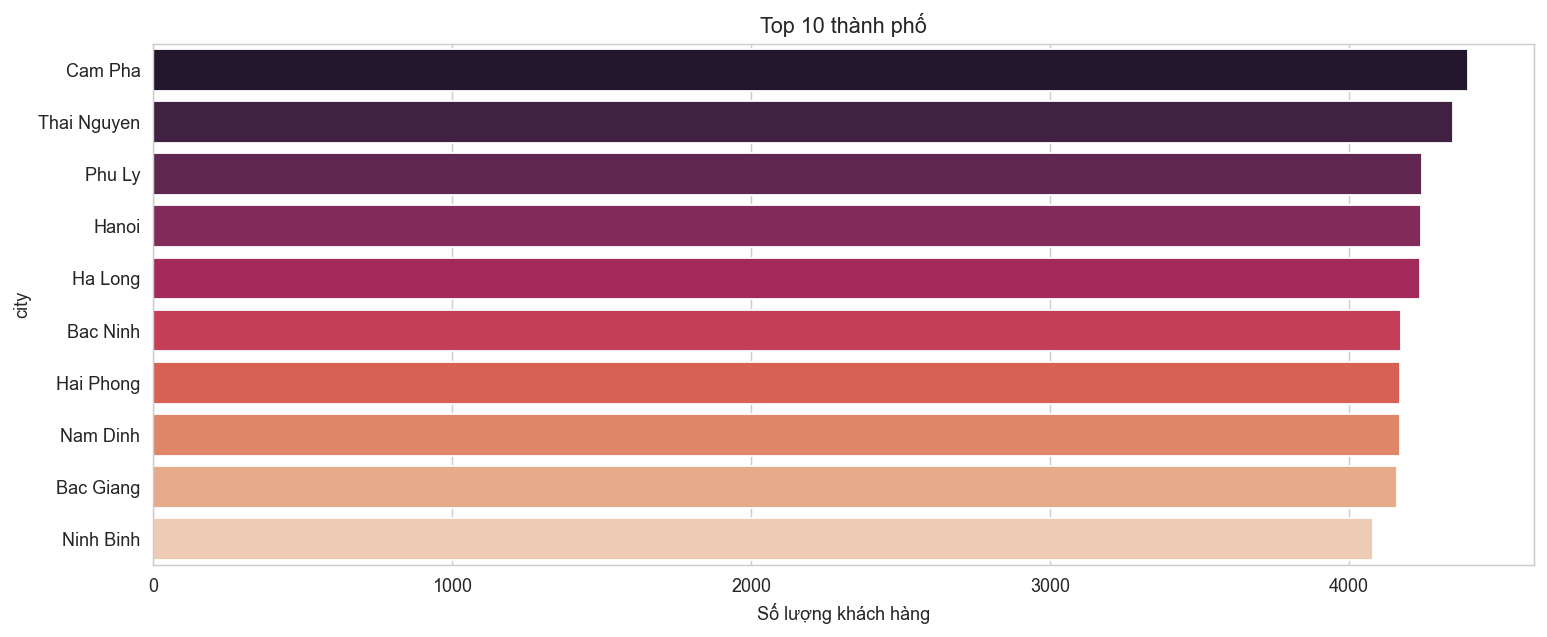


--- 1.3 ĐỊA LÝ: ĐỘ LỆCH THỊ TRƯỜNG (MARKET SKEW) ---
Độ lệch vùng miền (Market Skew Index): 0.32
Vùng trọng điểm: Bac Bo (47.7%)
Dù Bac Bo chiếm ưu thế, nhưng thành phố lớn nhất chỉ chiếm 3.6%
=> Insight: Khách hàng tập trung theo vùng nhưng phân tán rộng ở các đô thị vệ tinh, không chỉ dồn về đầu não.
Top 5 thành phố chiếm 17.6% tổng khách hàng
Thống kê số khách hàng trên mỗi zip code:
count    31491.000000
mean         3.871900
std          0.928899
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          6.000000
Name: count, dtype: float64


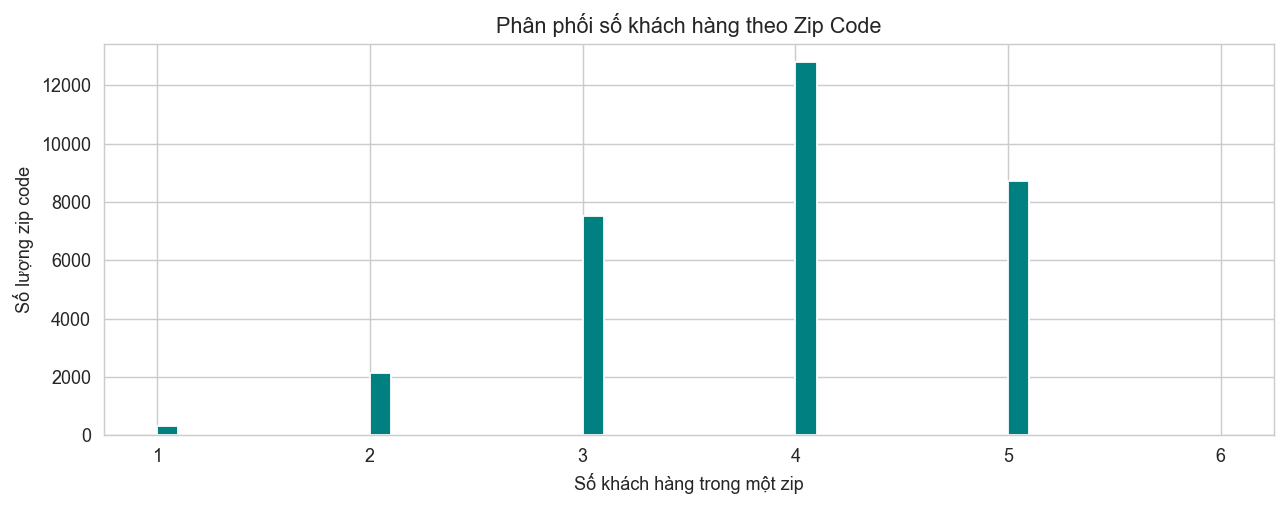


--- REGION (VÙNG MIỀN) ---
Phân bố region:
region
Bac Bo          58178
Nam Trung Bo    32817
Tay Nam Bo      12020
Bac Trung Bo     7631
Tay Nguyen       7501
Dong Nam Bo      3783
Name: count, dtype: int64
Tỉ lệ:
region
Bac Bo          47.71
Nam Trung Bo    26.91
Tay Nam Bo       9.86
Bac Trung Bo     6.26
Tay Nguyen       6.15
Dong Nam Bo      3.10
Name: count, dtype: float64


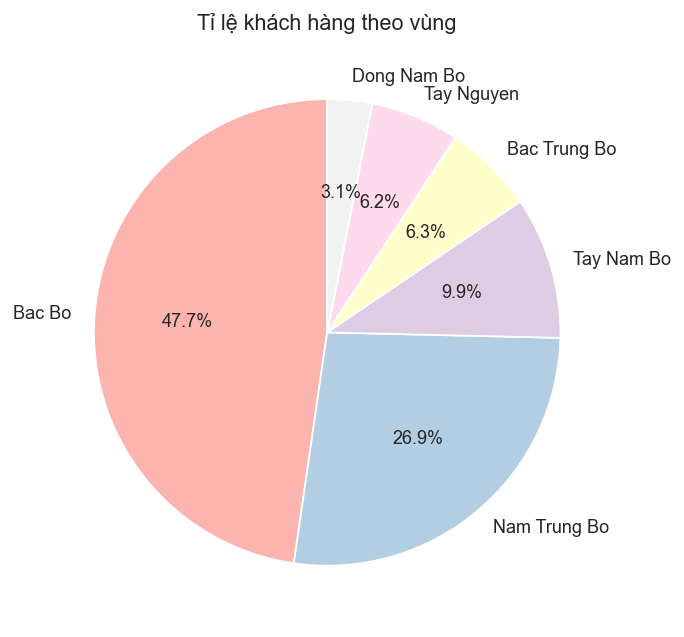


2. PHÂN TÍCH THỜI GIAN (SIGNUP_DATE)

--- 2. CHIẾN THUẬT THỜI GIAN: STORYTELLING & GROWTH ---
Phân tích tăng trưởng: Ngưỡng bùng nổ (Spike) được xác định tại mức > 21.2%
Phát hiện 4 điểm tăng trưởng vượt bậc. Cần đối soát với lịch sử Campaign/Expansion.
  year_quarter  count
2       2012Q3    304
3       2012Q4    422
4       2013Q1    566


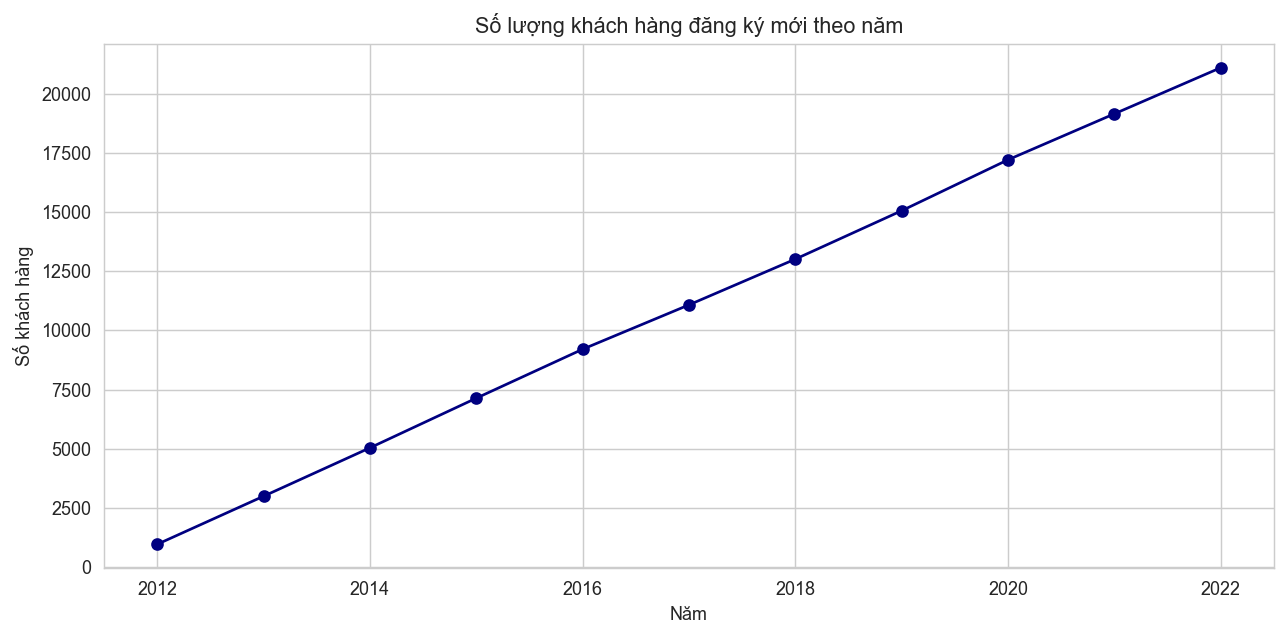

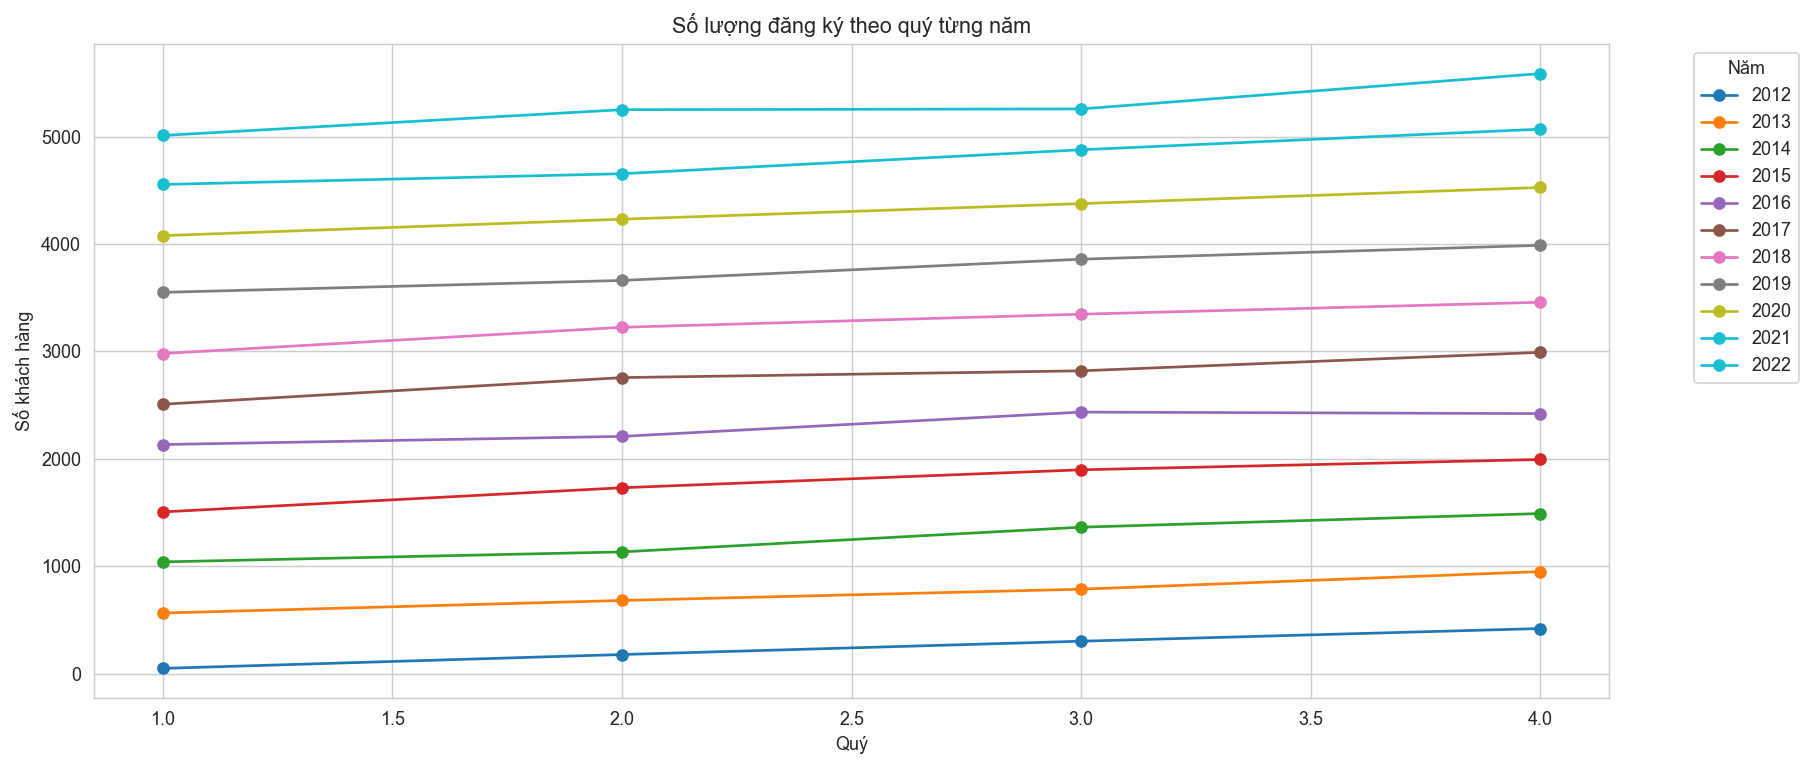


--- Thống kê số lượng đăng ký theo từng quý (tổng hợp 10 năm) ---
               Q1       Q2       Q3       Q4
mean      2543.82  2701.64  2848.00  2991.09
median    2509.00  2757.00  2820.00  2992.00
std       1652.44  1670.69  1658.67  1701.19
kurtosis    -1.21    -1.18    -1.19    -1.16
skewness     0.00    -0.01    -0.06     0.03


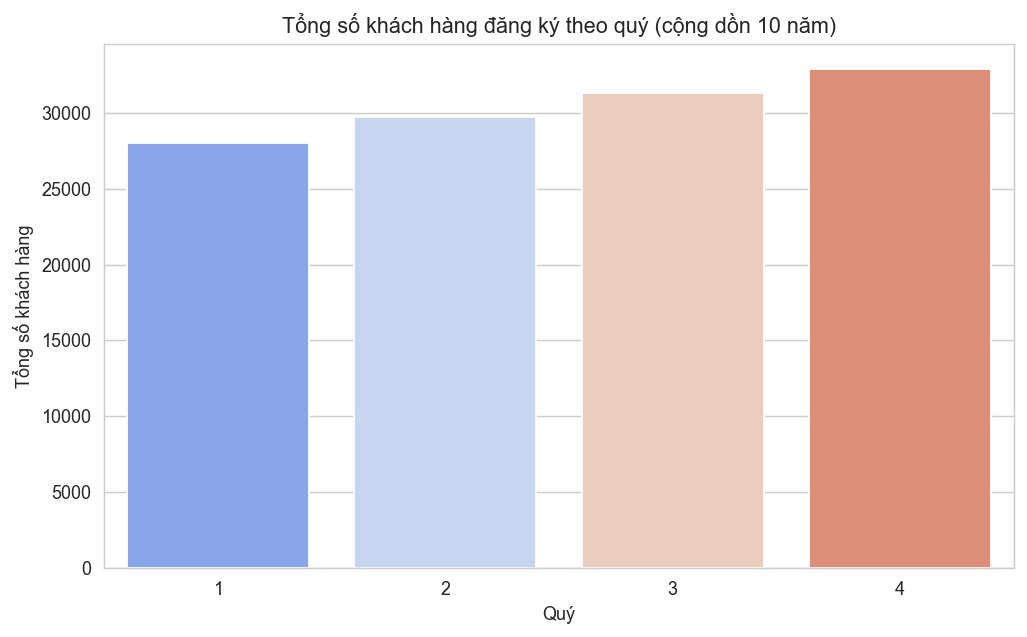

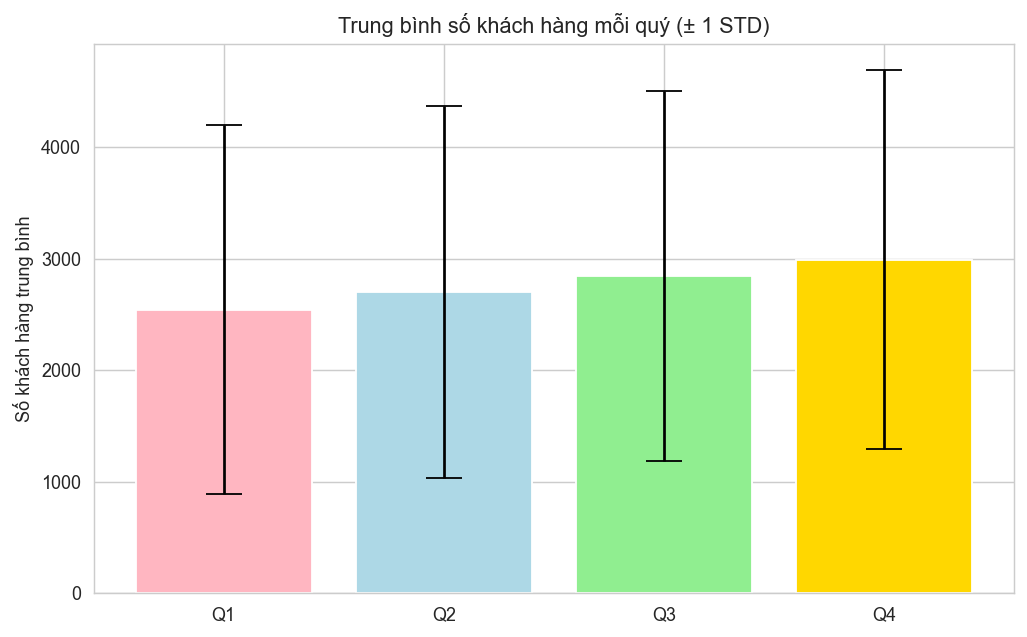


--- Tăng trưởng theo cụm 2 năm ---
Số lượng khách hàng theo từng cụm 2 năm:
biennial
2012-2013     3946
2014-2015    12167
2016-2017    20280
2018-2019    28069
2020-2022    57468
dtype: int64


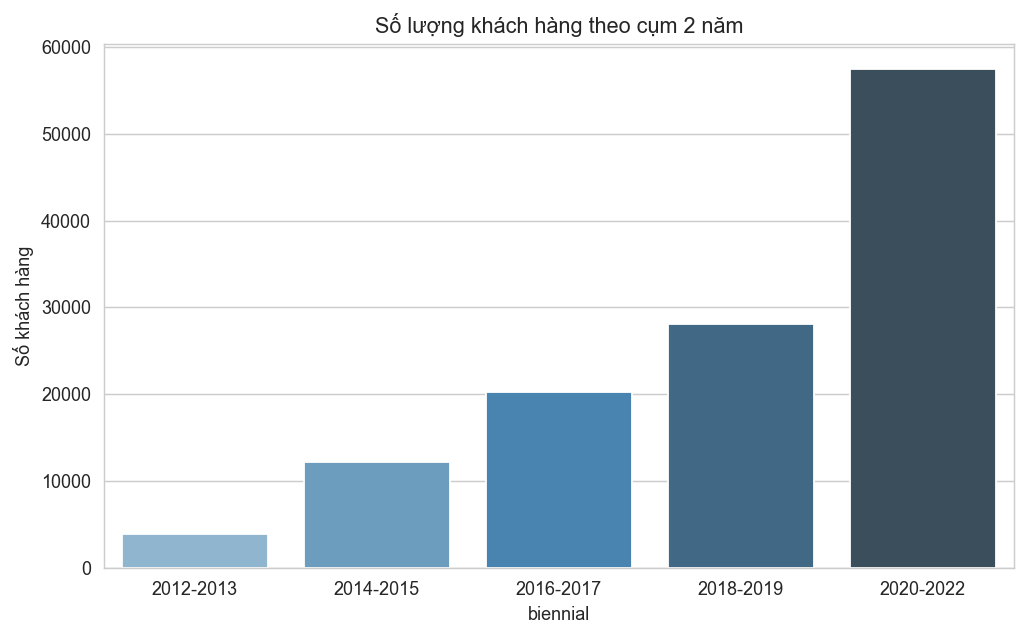


--- Phân tích tăng trưởng YoY / QoQ ---
Tăng trưởng theo quý (10 quý cuối):
year_quarter  count     QoQ_%     YoY_%
     2020-Q3   4376  3.427086 13.397253
     2020-Q4   4526  3.427788 13.490471
     2021-Q1   4554  0.618648 11.672388
     2021-Q2   4654  2.195872  9.997636
     2021-Q3   4877  4.791577 11.448812
     2021-Q4   5069  3.936846 11.997349
     2022-Q1   5010 -1.163938 10.013175
     2022-Q2   5250  4.790419 12.806188
     2022-Q3   5257  0.133333  7.791675
     2022-Q4   5586  6.258322 10.199250

Ngưỡng phát hiện bất thường QoQ: trung bình ± 2*std = 14.8% ± 78.5%
Các quý có tăng trưởng QoQ bất thường:
year_quarter  count      QoQ_%
     2012-Q2    180 252.941176
Các quý có tăng trưởng YoY bất thường:
year_quarter  count       YoY_%
     2013-Q1    566 1009.803922


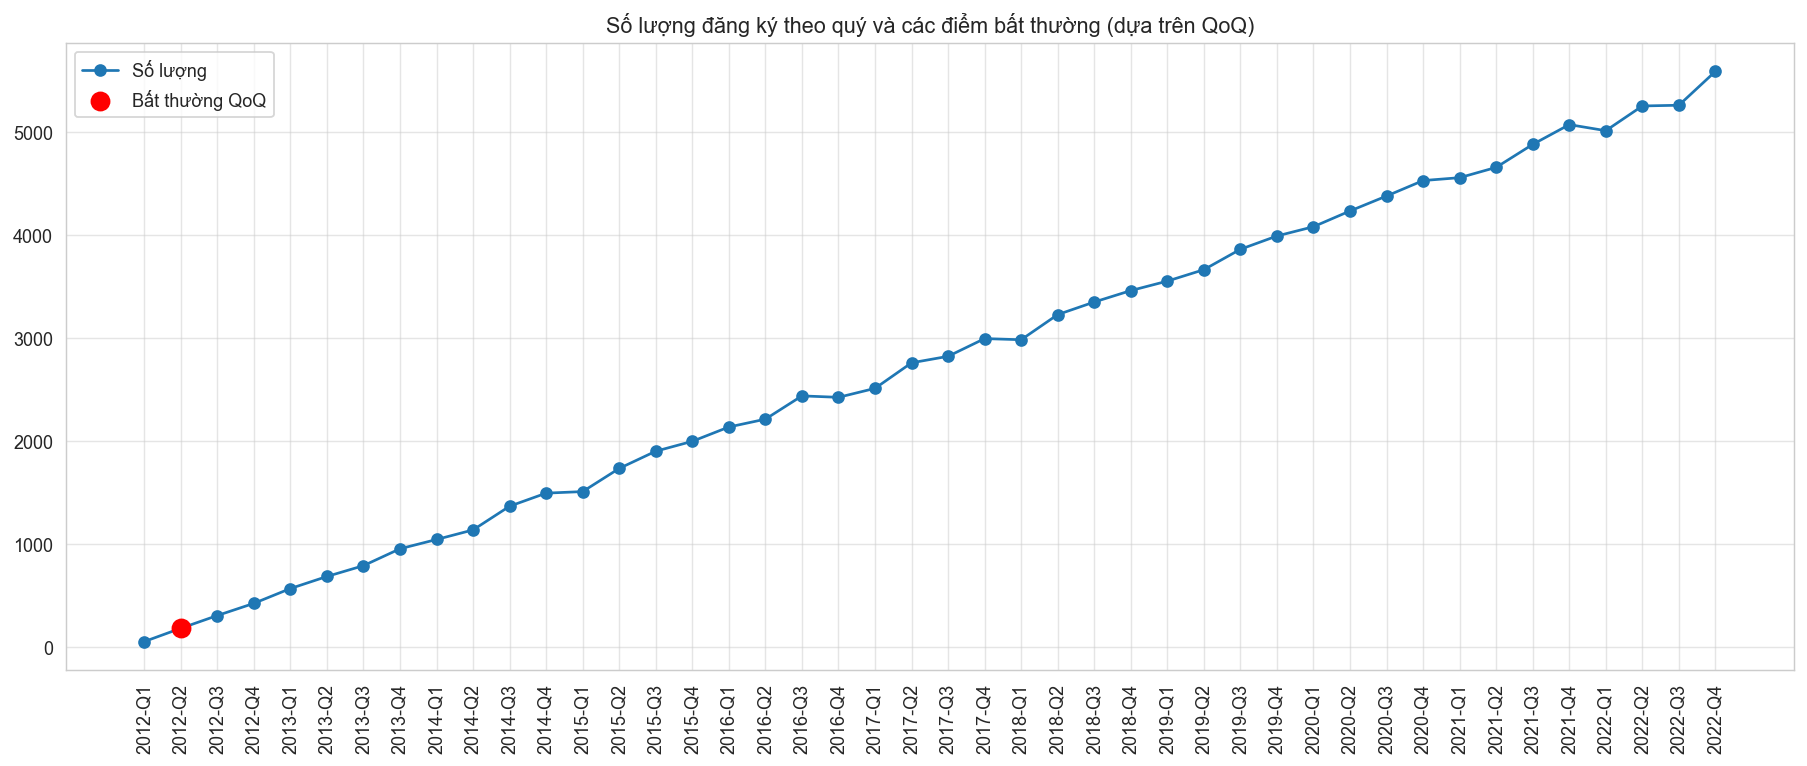


--- So sánh 5 năm đầu vs 5 năm cuối ---
Trung bình số đăng ký/quý (2012-2016): 1266
Trung bình số đăng ký/quý (2018-2022): 4277
Thay đổi: 237.9%

3. PHÂN TÍCH MỐI QUAN HỆ GIỮA CÁC THUỘC TÍNH

--- Kênh thu hút vs Nhóm tuổi ---


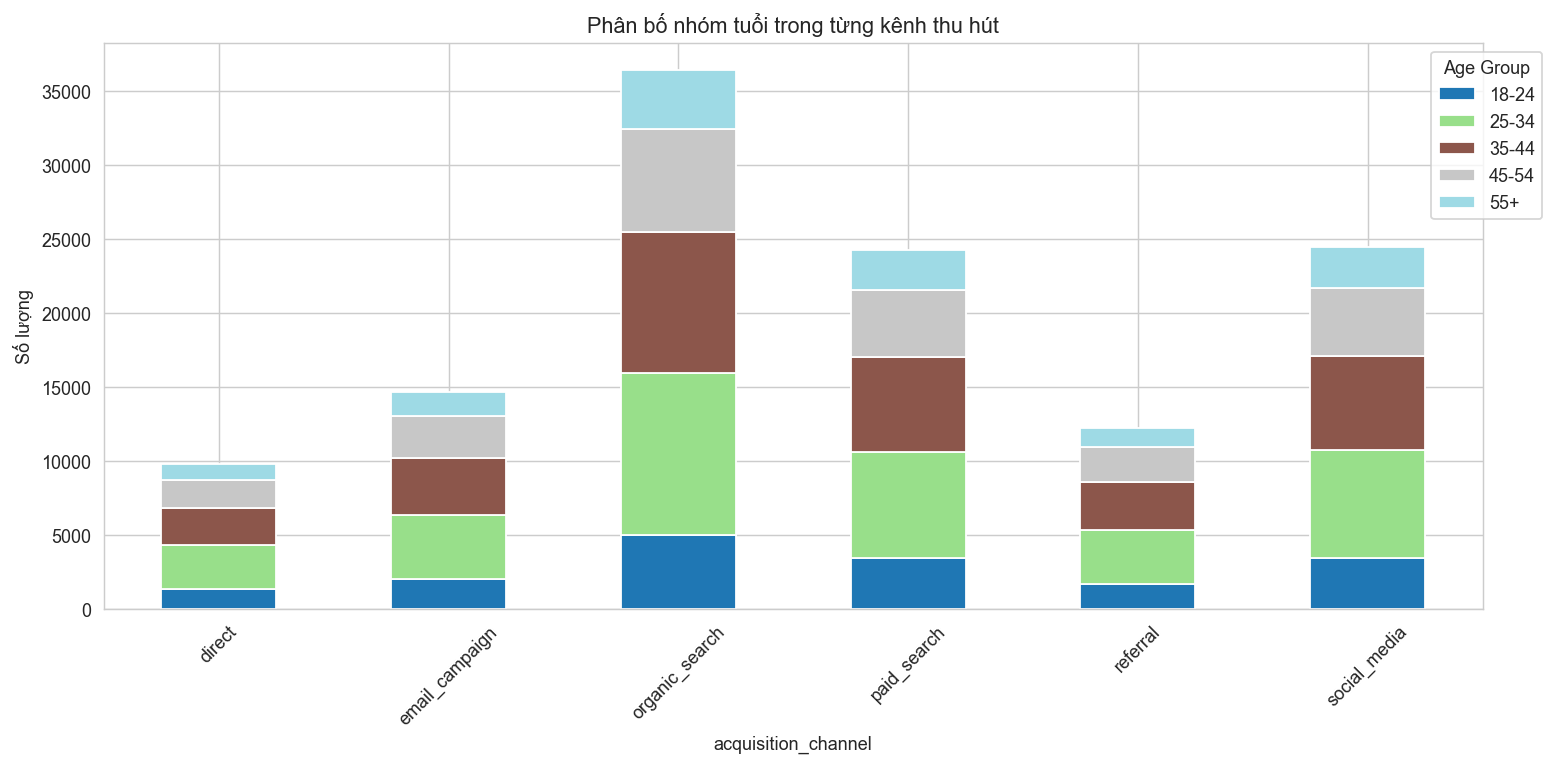

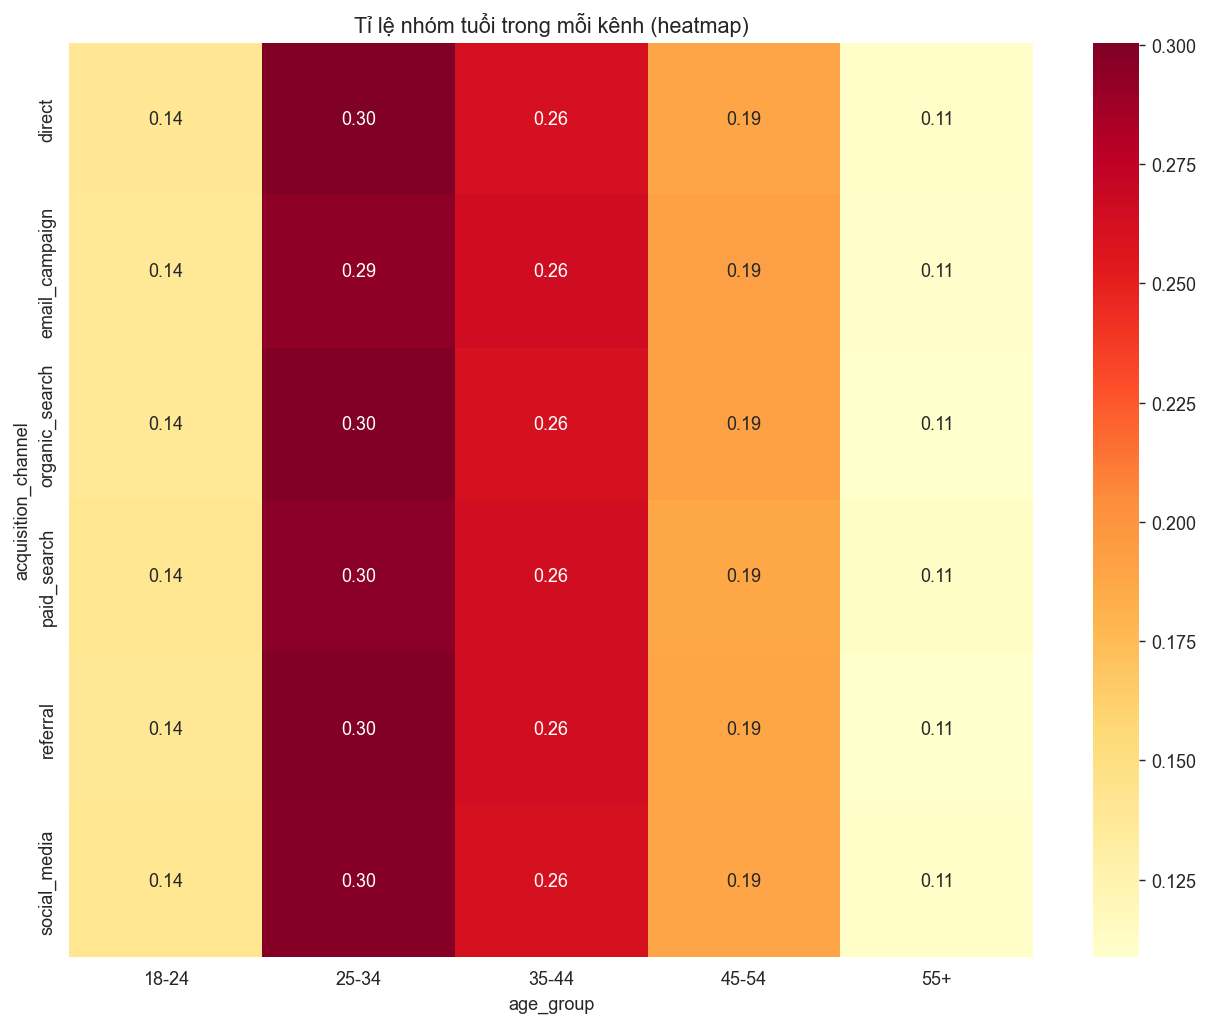

Chi-square test: chi2=10.47, p=0.9589 -> Không có bằng chứng liên hệ
Cramér's V = 0.005 (mức độ liên hệ)

--- Kênh thu hút vs Giới tính ---


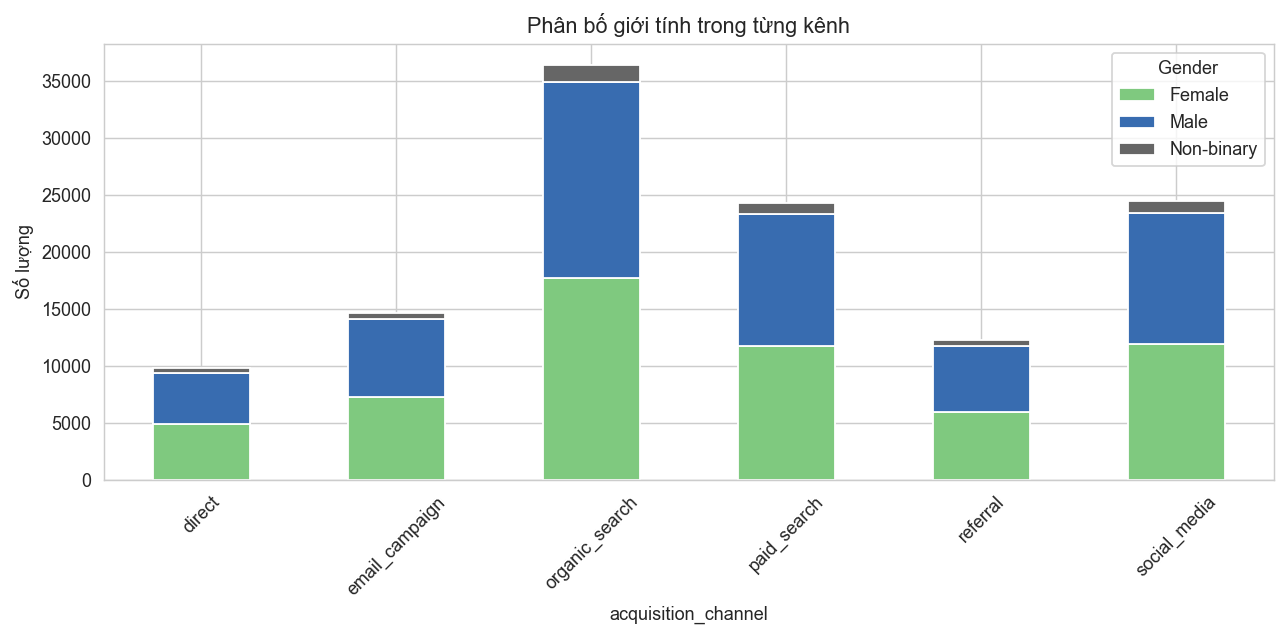

Chi-square test: chi2=16.25, p=0.0928 -> Không có bằng chứng liên hệ

--- Kênh thu hút vs Vùng miền ---


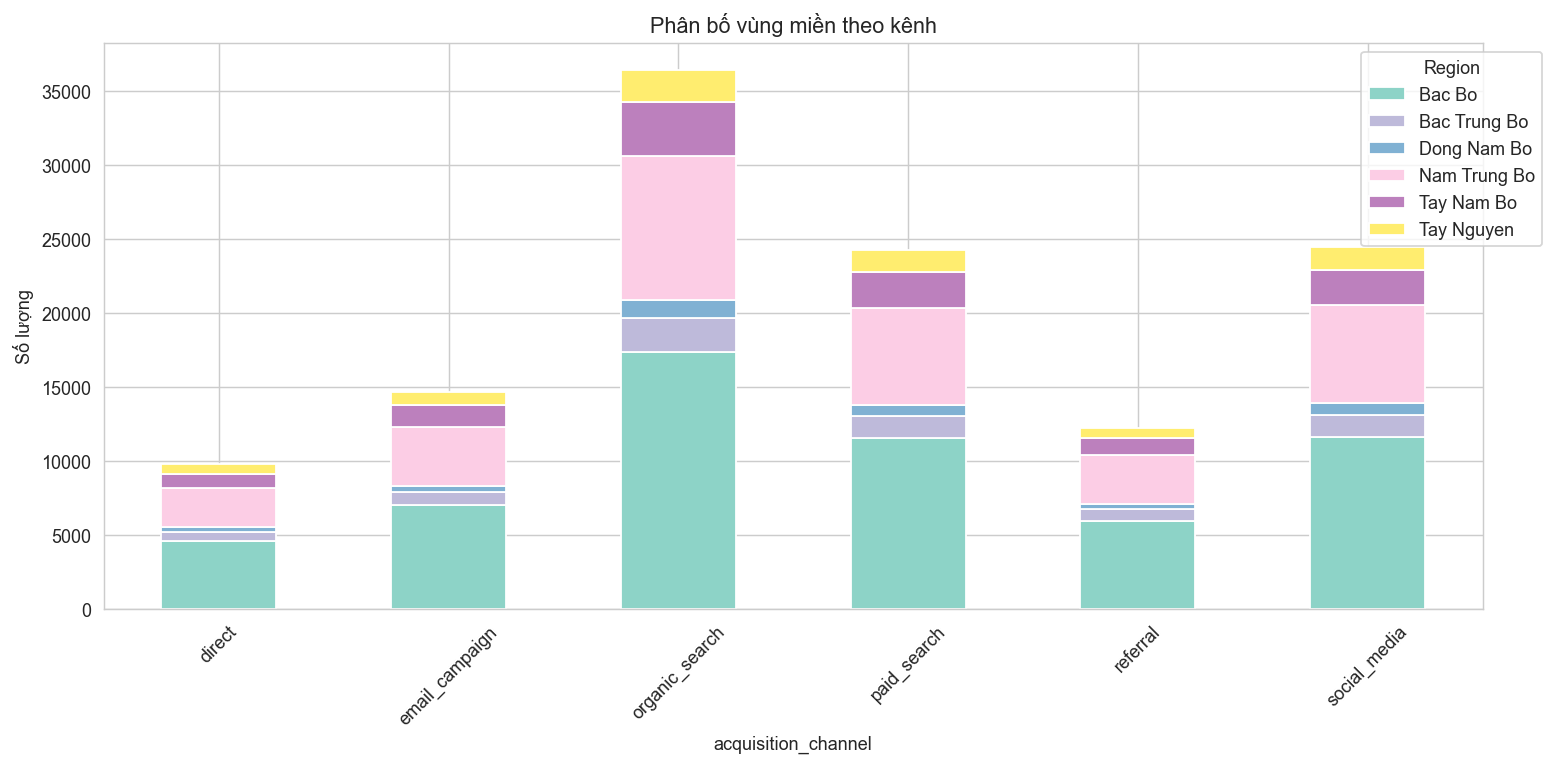

Chi-square test: chi2=22.67, p=0.5966 -> Không có bằng chứng liên hệ

--- Xu hướng đăng ký theo kênh (theo quý) ---


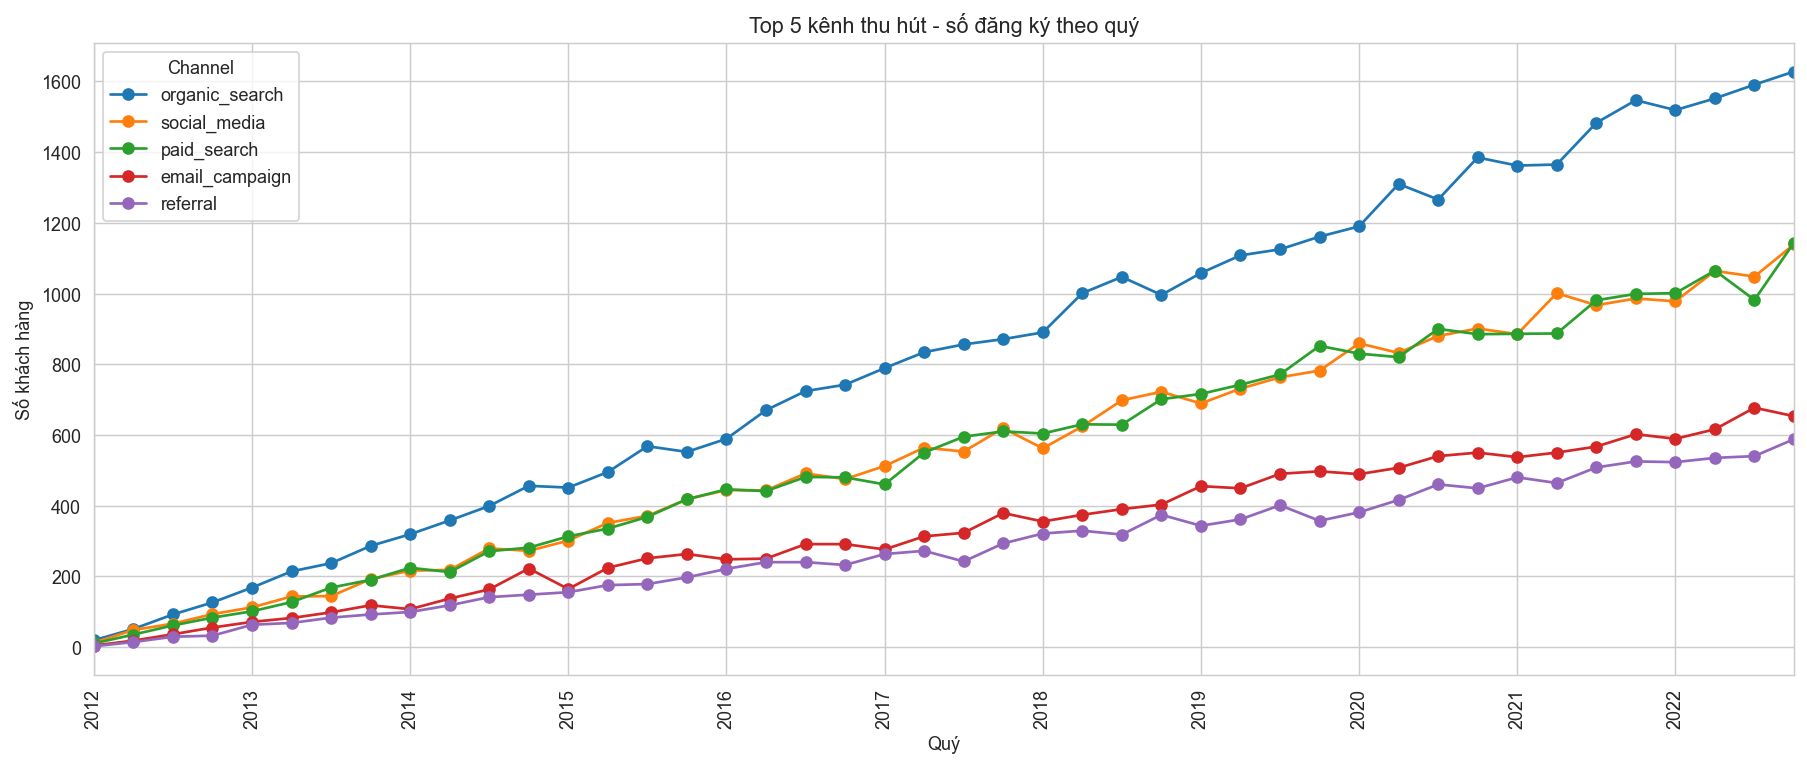


--- Nhóm tuổi theo Vùng miền ---


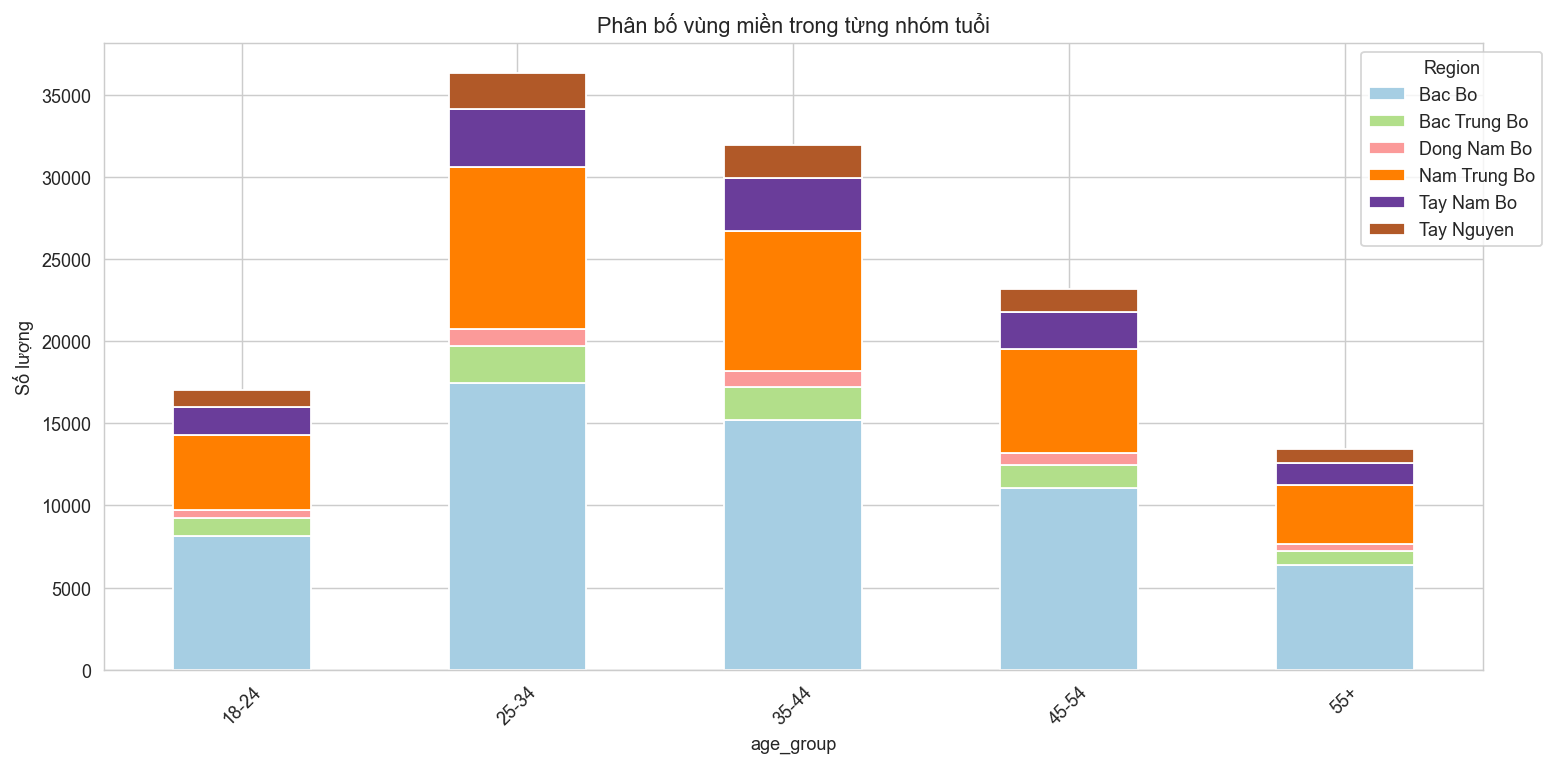


4. ĐỀ XUẤT CÁC CÔNG CỤ PHÂN TÍCH BỔ SUNG

    1. Phân tích Cohort Retention: theo dõi tỉ lệ quay lại của khách hàng theo tháng đăng ký đầu tiên (cần dữ liệu giao dịch/hoạt động).
    2. RFM Segmentation: phân nhóm khách hàng dựa trên Recency, Frequency, Monetary (nếu có dữ liệu mua hàng).
    3. Phân cụm (Clustering) khách hàng: sử dụng K-means trên các đặc điểm nhân khẩu học để tìm phân khúc ẩn.
    4. Geographic Heatmap: trực quan hóa mật độ khách hàng trên bản đồ (cần tọa độ zip/city).
    5. Phân tích chuỗi thời gian nâng cao: dùng STL decomposition hoặc Facebook Prophet để dự báo số lượng đăng ký.
    6. Kiểm định ANOVA/Kruskal-Wallis so sánh tenure giữa các nhóm kênh/vùng.
    7. Phân tích survival (đối với rời bỏ): ước lượng thời gian khách hàng “sống” nếu có dữ liệu churn.
    8. Phân tích quan hệ đa biến: sử dụng Decision Tree để xem biến nào ảnh hưởng mạnh đến kênh thu hút hoặc nhóm tuổi.
    
Ví dụ: Kiểm định Kruskal-Wallis tenure (ngày) giữa các kênh thu hút:
H = 3.41, p =

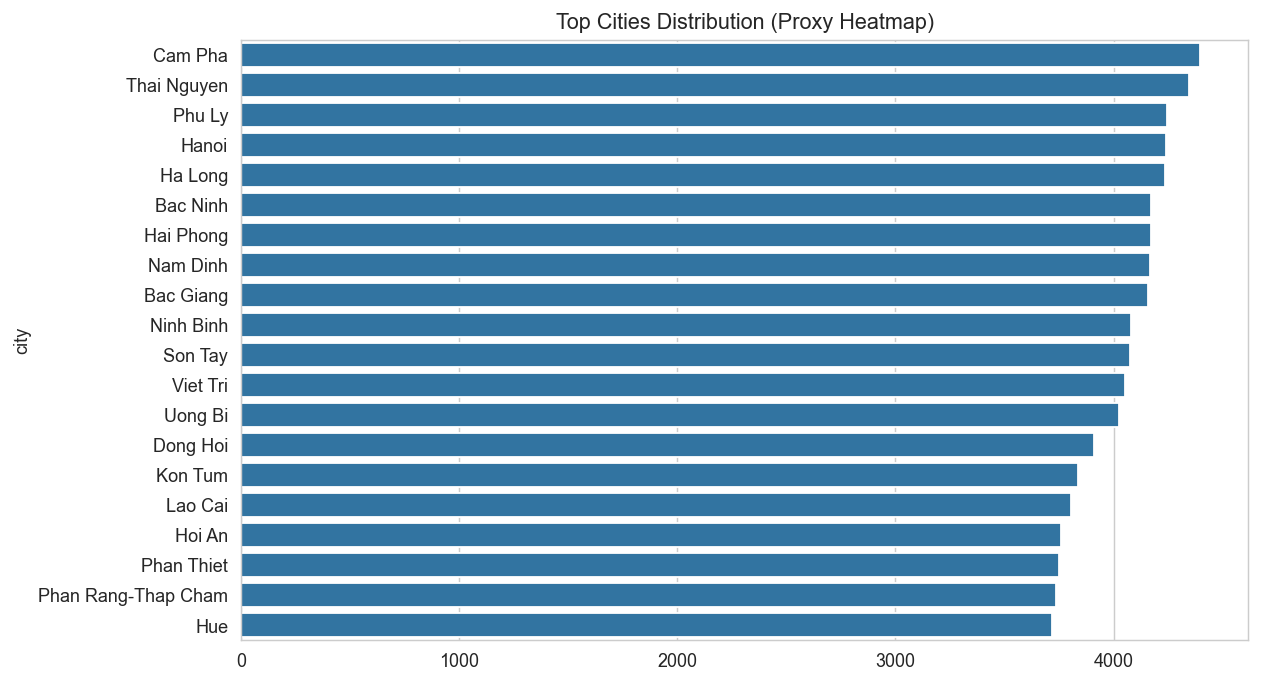


=== TIME SERIES STL DECOMPOSITION ===


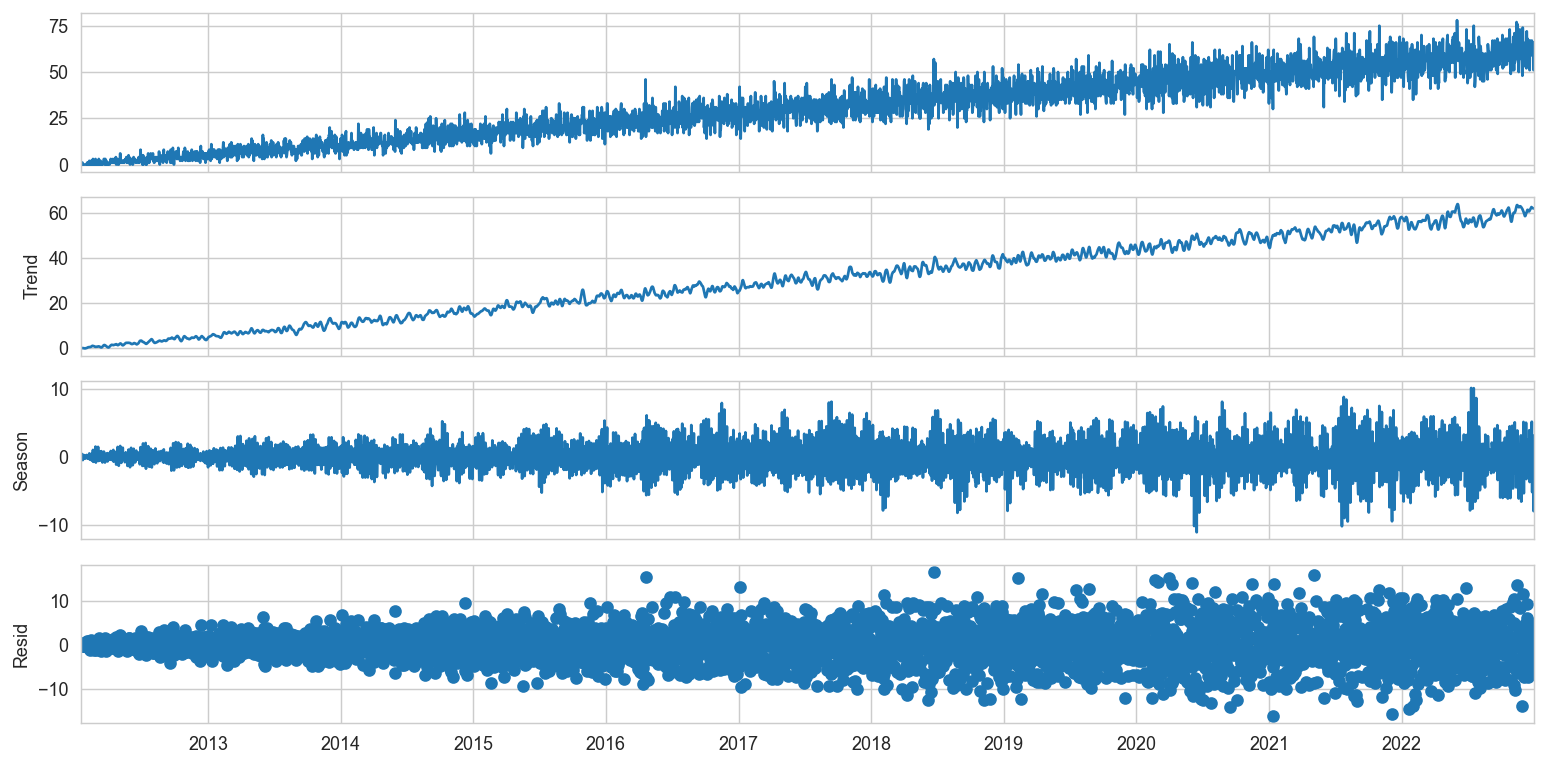


=== TENURE ANOVA / KRUSKAL ===
Kruskal: stat=1.93, p=0.8592

=== SURVIVAL ANALYSIS ===
⚠️ Thiếu biến churn.

=== DECISION TREE ANALYSIS ===


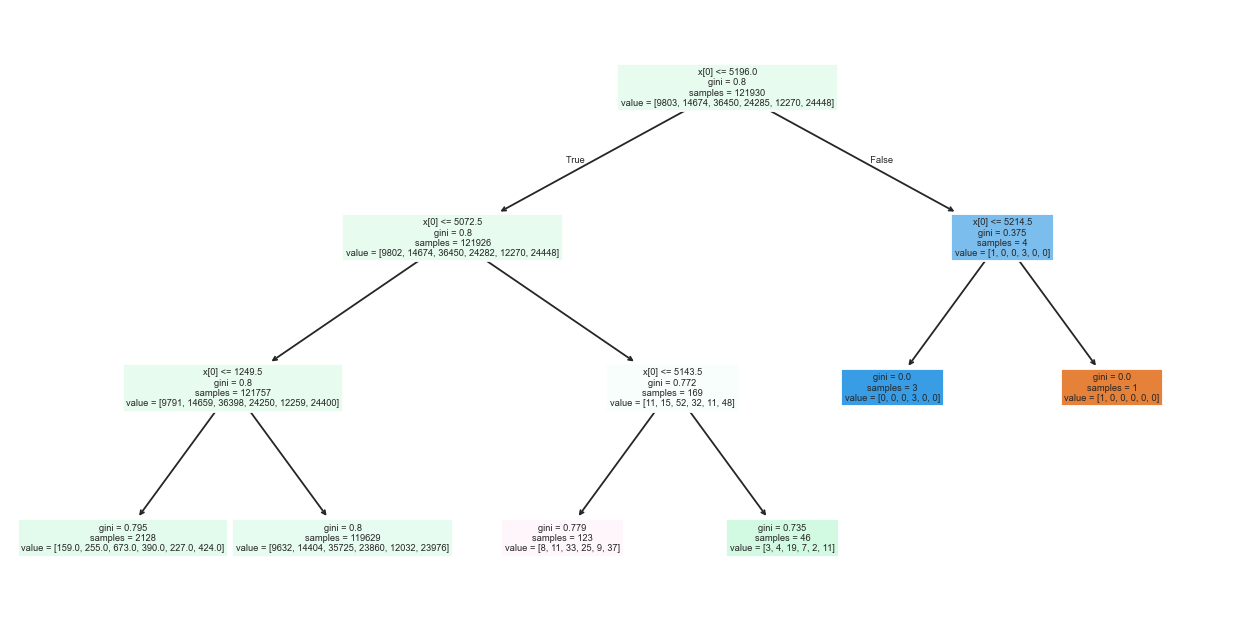

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, kruskal
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

############################################################################
# 5. CÁC HÀM PHÂN TÍCH NÂNG CAO (BỔ SUNG)
############################################################################

# 1. Cohort Retention Analysis
def cohort_retention(df):
    print("\n=== COHORT RETENTION ANALYSIS ===")
    data = df.copy()
    data['signup_month'] = data['signup_date'].dt.to_period('M')
    
    cohort = data.groupby(['signup_month']).size()
    print("Cohort size theo tháng:")
    print(cohort.head())

    # Nếu có activity_date thì mới làm retention chuẩn
    if 'activity_date' in data.columns:
        data['activity_month'] = pd.to_datetime(data['activity_date']).dt.to_period('M')
        cohort_data = data.groupby(['signup_month', 'activity_month']).size().unstack(fill_value=0)
        retention = cohort_data.divide(cohort_data.iloc[:,0], axis=0)
        
        plt.figure(figsize=(10,6))
        sns.heatmap(retention, cmap='Blues')
        plt.title("Cohort Retention Heatmap")
        plt.show()
    else:
        print("⚠️ Thiếu cột activity_date → chưa thể tính retention chuẩn.")


# 2. RFM Segmentation
def rfm_segmentation(df):
    print("\n=== RFM SEGMENTATION ===")
    if not {'customer_id','purchase_date','amount'}.issubset(df.columns):
        print("⚠️ Thiếu dữ liệu giao dịch.")
        return
    
    data = df.copy()
    data['purchase_date'] = pd.to_datetime(data['purchase_date'])
    snapshot_date = data['purchase_date'].max()
    
    rfm = data.groupby('customer_id').agg({
        'purchase_date': lambda x: (snapshot_date - x.max()).days,
        'customer_id': 'count',
        'amount': 'sum'
    })
    
    rfm.columns = ['Recency', 'Frequency', 'Monetary']
    print(rfm.describe())


# 3. Customer Clustering (KMeans)
def customer_clustering(df):
    print("\n=== CUSTOMER CLUSTERING (KMEANS) ===")
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    
    features = df[['age_group','region']].astype('category').apply(lambda x: x.cat.codes)
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    
    kmeans = KMeans(n_clusters=4, random_state=42)
    df['cluster'] = kmeans.fit_predict(X)
    
    print(df['cluster'].value_counts())


# 4. Geographic Heatmap (basic)
def geographic_heatmap(df):
    print("\n=== GEOGRAPHIC HEATMAP ===")
    geo = df.groupby('city').size().sort_values(ascending=False).head(20)
    
    plt.figure(figsize=(10,6))
    sns.barplot(x=geo.values, y=geo.index)
    plt.title("Top Cities Distribution (Proxy Heatmap)")
    plt.show()


# 5. Time Series Forecast (STL)
def time_series_stl(df):
    print("\n=== TIME SERIES STL DECOMPOSITION ===")
    from statsmodels.tsa.seasonal import STL
    
    ts = df.groupby('signup_date').size()
    ts = ts.asfreq('D').fillna(0)
    
    stl = STL(ts)
    result = stl.fit()
    result.plot()
    plt.show()


# 6. ANOVA / Kruskal-Wallis
def tenure_anova(df):
    print("\n=== TENURE ANOVA / KRUSKAL ===")
    groups = [g['tenure_days'].values for _, g in df.groupby('region')]
    
    stat, p = kruskal(*groups)
    print(f"Kruskal: stat={stat:.2f}, p={p:.4f}")


# 7. Survival Analysis (Kaplan-Meier)
def survival_analysis(df):
    print("\n=== SURVIVAL ANALYSIS ===")
    if 'churn' not in df.columns:
        print("⚠️ Thiếu biến churn.")
        return
    
    from lifelines import KaplanMeierFitter
    
    kmf = KaplanMeierFitter()
    kmf.fit(df['tenure_days'], event_observed=df['churn'])
    kmf.plot_survival_function()
    plt.title("Customer Survival Curve")
    plt.show()


# 8. Decision Tree Analysis
def decision_tree_analysis(df):
    print("\n=== DECISION TREE ANALYSIS ===")
    from sklearn.tree import DecisionTreeClassifier, plot_tree
    
    X = df[['tenure_days']]
    y = df['acquisition_channel']
    
    model = DecisionTreeClassifier(max_depth=3)
    model.fit(X, y)
    
    plt.figure(figsize=(12,6))
    plot_tree(model, filled=True)
    plt.show()


# Gọi thêm nếu cần
# run_advanced_analysis(customers)

def run_full_analysis(df):
    """
    Phân tích toàn diện dữ liệu khách hàng:
    - Univariate: phân phối từng thuộc tính (bao gồm signup_date theo quý, cụm 2 năm)
    - Bivariate: mối quan hệ giữa các biến categorical
    - Phân tích tăng trưởng YoY, QoQ, phát hiện bất thường
    - Đề xuất công cụ phân tích bổ sung
    """
    ############################################################################
    # 0. TIỀN XỬ LÝ
    ############################################################################
    print("="*80)
    print("BẮT ĐẦU PHÂN TÍCH DỮ LIỆU KHÁCH HÀNG")
    print("="*80)
    
    # Sao chép để tránh ảnh hưởng dữ liệu gốc
    data = df.copy()
    
    # Chuyển đổi signup_date sang datetime
    data['signup_date'] = pd.to_datetime(data['signup_date'])
    
    
    # Tạo các biến thời gian
    data['year'] = data['signup_date'].dt.year
    data['quarter'] = data['signup_date'].dt.quarter
    data['month'] = data['signup_date'].dt.month
    data['year_quarter'] = data['signup_date'].dt.to_period('Q')
    # tenure (số ngày từ signup đến cuối 2022)
    end_date = pd.Timestamp('2022-12-31')
    data['tenure_days'] = (end_date - data['signup_date']).dt.days
    
    # Phân nhóm 2 năm
    bins = [2012, 2014, 2016, 2018, 2020, 2023]  # 2023 là biên phải
    labels = ['2012-2013', '2014-2015', '2016-2017', '2018-2019', '2020-2022']  # nhóm cuối 3 năm do dữ liệu đến 2022
    data['biennial'] = pd.cut(data['year'], bins=bins, labels=labels, right=False)
    
    ############################################################################
    # 1. PHÂN TÍCH ĐƠN BIẾN (UNIVARIATE)
    ############################################################################
    print("\n" + "="*60)
    print("1. PHÂN TÍCH ĐƠN BIẾN - CẤU TRÚC KHÁCH HÀNG")
    print("="*60)
    
    # ---- acquisition_channel ----
    print("\n--- ACQUISITION CHANNEL ---")
    channel_counts = data['acquisition_channel'].value_counts()
    channel_pct = data['acquisition_channel'].value_counts(normalize=True)*100
    print("Số lượng và tỉ lệ khách hàng theo kênh:")
    print(pd.DataFrame({'Count': channel_counts, 'Percentage': channel_pct.round(2)}))
    
    # Biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    sns.countplot(data=data, y='acquisition_channel', order=channel_counts.index, palette='viridis', ax=axes[0])
    axes[0].set_title('Số lượng khách hàng theo kênh thu hút')
    axes[1].pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(channel_counts)))
    axes[1].set_title('Tỉ lệ khách hàng theo kênh')
    plt.tight_layout()
    plt.show()

    channel_counts = data['acquisition_channel'].value_counts()
    channel_pct = data['acquisition_channel'].value_counts(normalize=True)
    
    # Chỉ số Concentration (Top 3 Dominance)
    top3_share = channel_pct.head(3).sum() * 100
    # Chỉ số Entropy (Độ đa dạng của kênh - Càng cao càng ít rủi ro phụ thuộc)
    channel_entropy = stats.entropy(channel_pct)
    
    print(f"Insight: Top 3 kênh chiếm {top3_share:.1f}% tổng lượng khách.")
    print(f"Chỉ số đa dạng kênh (Entropy): {channel_entropy:.2f}")
    
    if top3_share > 70:
        print("🚨 RISK: Doanh nghiệp đang phụ thuộc quá lớn vào một vài kênh chính. Cần đa dạng hóa.")
    else:
        print("✅ Tín hiệu: Cơ cấu kênh thu hút khá lành mạnh, rủi ro dàn trải được kiểm soát.")
    
    # Kiểm định Chi-square so với phân phối đều (nếu cần)
    chi2, p = stats.chisquare(channel_counts)
    print(f"Kiểm định Chi-square (phân phối đều): chi2={chi2:.2f}, p={p:.4f} -> {'Không đồng đều' if p<0.05 else 'Có thể đồng đều'}")
    
    # ---- age_group & gender ----
    print("\n--- AGE GROUP & GENDER ---")
    age_gender = pd.crosstab(data['age_group'], data['gender'])
    print("Phân phối chung Age group vs Gender:")
    print(age_gender)
    print("\nTỉ lệ phần trăm theo dòng:")
    print(age_gender.div(age_gender.sum(axis=1), axis=0).round(3)*100)

    print("\n--- 1.2 NHÂN KHẨU HỌC: ĐỘ TRUNG THỰC CỦA DỮ LIỆU ---")
    # Kiểm tra tính "phẳng" (Uniformity) của dữ liệu
    age_dist = data['age_group'].value_counts(normalize=True)
    is_synthetic_signal = age_dist.std() < 0.05 # Nếu độ lệch chuẩn giữa các nhóm quá thấp
    
    if is_synthetic_signal:
        print("⚠️ CẢNH BÁO: Phân bố tuổi/giới tính cực kỳ đồng đều (Uniform Distribution).")
        print("Dấu hiệu này cho thấy dữ liệu có thể là Synthetic (giả lập) hoặc chiến lược Marketing đang 'Mass-market' hoàn toàn, không có Target Audience cụ thể.")
    else:
        print(f"Nhóm khách hàng nòng cốt: {age_dist.idxmax()} ({age_dist.max()*100:.1f}%)")
    
    # Biểu đồ stacked bar
    age_gender.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10,6))
    plt.title('Phân bố Age Group theo Gender (Stacked)')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.legend(title='Gender')
    plt.tight_layout()
    plt.show()
    
    # Mode (nhóm phổ biến nhất)
    mode_age = data['age_group'].mode()[0]
    mode_gender = data['gender'].mode()[0]
    print(f"Nhóm tuổi phổ biến nhất: {mode_age}, Giới tính phổ biến nhất: {mode_gender}")
    
    # Heatmap (tương quan tuổi-giới tính)
    plt.figure(figsize=(8,5))
    sns.heatmap(age_gender, annot=True, fmt='d', cmap='YlGnBu')
    plt.title('Heatmap số lượng Age Group vs Gender')
    plt.tight_layout()
    plt.show()
    
    # ---- city & zip ----
    print("\n--- GEOGRAPHIC (CITY, ZIP) ---")
    top_cities = data['city'].value_counts().head(10)
    print("Top 10 thành phố có nhiều khách hàng nhất:")
    print(top_cities)
    plt.figure(figsize=(12,5))
    sns.barplot(x=top_cities.values, y=top_cities.index, palette='rocket')
    plt.title('Top 10 thành phố')
    plt.xlabel('Số lượng khách hàng')
    plt.tight_layout()
    plt.show()

    print("\n--- 1.3 ĐỊA LÝ: ĐỘ LỆCH THỊ TRƯỜNG (MARKET SKEW) ---")
    region_pct = data['region'].value_counts(normalize=True)
    # Hệ số Gini đơn giản hóa để đo độ tập trung vùng miền (0: đều, 1: tập trung 1 chỗ)
    market_skew = (region_pct**2).sum() 
    
    print(f"Độ lệch vùng miền (Market Skew Index): {market_skew:.2f}")
    print(f"Vùng trọng điểm: {region_pct.idxmax()} ({region_pct.max()*100:.1f}%)")
    
    # So sánh City vs Region
    top_city_share = data['city'].value_counts(normalize=True).head(1).values[0] * 100
    print(f"Dù {region_pct.idxmax()} chiếm ưu thế, nhưng thành phố lớn nhất chỉ chiếm {top_city_share:.1f}%")
    print("=> Insight: Khách hàng tập trung theo vùng nhưng phân tán rộng ở các đô thị vệ tinh, không chỉ dồn về đầu não.")
    
    # Tính mức độ tập trung: % khách hàng của top 5 thành phố
    top5_share = data['city'].value_counts(normalize=True).head(5).sum()*100
    print(f"Top 5 thành phố chiếm {top5_share:.1f}% tổng khách hàng")
    
    # Phân phối zip code (có thể quá nhiều, nên xem thống kê)
    zip_counts = data['zip'].value_counts()
    print("Thống kê số khách hàng trên mỗi zip code:")
    print(zip_counts.describe())
    plt.figure(figsize=(10,4))
    zip_counts.hist(bins=50, color='teal')
    plt.title('Phân phối số khách hàng theo Zip Code')
    plt.xlabel('Số khách hàng trong một zip')
    plt.ylabel('Số lượng zip code')
    plt.tight_layout()
    plt.show()
    
    # ---- region ----
    print("\n--- REGION (VÙNG MIỀN) ---")
    region_counts = data['region'].value_counts()
    print("Phân bố region:")
    print(region_counts)
    print("Tỉ lệ:")
    print((region_counts/len(data)*100).round(2))
    plt.figure(figsize=(8,5))
    region_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
    plt.title('Tỉ lệ khách hàng theo vùng')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
    
    ############################################################################
    # 2. PHÂN TÍCH SIGNUP_DATE (THỜI GIAN)
    ############################################################################
    print("\n" + "="*60)
    print("2. PHÂN TÍCH THỜI GIAN (SIGNUP_DATE)")
    print("="*60)

    print("\n--- 2. CHIẾN THUẬT THỜI GIAN: STORYTELLING & GROWTH ---")
    
    # Xử lý Early-stage bias cho Spike Detection
    quarterly_data = data.groupby('year_quarter').size().reset_index(name='count')
    # Loại bỏ 4 quý đầu tiên khi tính ngưỡng bất thường để tránh Base thấp làm nhiễu Std
    baseline_growth = quarterly_data['count'].pct_change()
    stable_growth = baseline_growth.iloc[4:] 
    
    q_mean, q_std = stable_growth.mean(), stable_growth.std()
    upper_threshold = q_mean + 2*q_std
    
    anomalies = quarterly_data[baseline_growth > upper_threshold]
    
    print(f"Phân tích tăng trưởng: Ngưỡng bùng nổ (Spike) được xác định tại mức > {upper_threshold*100:.1f}%")
    if not anomalies.empty:
        print(f"Phát hiện {len(anomalies)} điểm tăng trưởng vượt bậc. Cần đối soát với lịch sử Campaign/Expansion.")
        print(anomalies[['year_quarter', 'count']].tail(3))
    
    # ---- Tổng quan signup theo năm và quý ----
    yearly = data.groupby('year').size()
    quarterly = data.groupby(['year', 'quarter']).size().unstack(fill_value=0)
    
    # Biểu đồ đường số lượng theo năm
    plt.figure(figsize=(10,5))
    yearly.plot(marker='o', linestyle='-', color='navy')
    plt.title('Số lượng khách hàng đăng ký mới theo năm')
    plt.xlabel('Năm')
    plt.ylabel('Số khách hàng')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Biểu đồ đường theo quý (từng năm)
    quarterly.T.plot(marker='o', figsize=(14,6), colormap='tab10')
    plt.title('Số lượng đăng ký theo quý từng năm')
    plt.xlabel('Quý')
    plt.ylabel('Số khách hàng')
    plt.legend(title='Năm', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ---- PHÂN TÍCH THEO QUÝ XUYÊN SUỐT 10 NĂM ----
    print("\n--- Thống kê số lượng đăng ký theo từng quý (tổng hợp 10 năm) ---")
    # Gom nhóm theo quý (1,2,3,4) và tính các chỉ số
    quarter_stats = quarterly.agg(['mean', 'median', 'std', 
                                   lambda x: x.kurtosis(), 
                                   lambda x: x.skew()])
    quarter_stats.index = ['mean', 'median', 'std', 'kurtosis', 'skewness']
    quarter_stats.columns = ['Q1', 'Q2', 'Q3', 'Q4']
    print(quarter_stats.round(2))
    
    # Counting plot: tổng số đăng ký mỗi quý (cộng dồn 10 năm) và trung bình ± std
    total_by_quarter = quarterly.sum()
    plt.figure(figsize=(8,5))
    sns.barplot(x=total_by_quarter.index, y=total_by_quarter.values, palette='coolwarm')
    plt.title('Tổng số khách hàng đăng ký theo quý (cộng dồn 10 năm)')
    plt.xlabel('Quý')
    plt.ylabel('Tổng số khách hàng')
    plt.tight_layout()
    plt.show()
    
    # Biểu đồ trung bình ± std
    means = quarter_stats.loc['mean']
    stds = quarter_stats.loc['std']
    plt.figure(figsize=(8,5))
    plt.bar(means.index, means, yerr=stds, capsize=10, color=['#FFB6C1','#ADD8E6','#90EE90','#FFD700'])
    plt.title('Trung bình số khách hàng mỗi quý (± 1 STD)')
    plt.ylabel('Số khách hàng trung bình')
    plt.tight_layout()
    plt.show()
    
    # ---- PHÂN TÍCH THEO CỤM 2 NĂM ----
    print("\n--- Tăng trưởng theo cụm 2 năm ---")
    biennial_counts = data.groupby('biennial').size()
    print("Số lượng khách hàng theo từng cụm 2 năm:")
    print(biennial_counts)
    plt.figure(figsize=(8,5))
    sns.barplot(x=biennial_counts.index.astype(str), y=biennial_counts.values, palette='Blues_d')
    plt.title('Số lượng khách hàng theo cụm 2 năm')
    plt.ylabel('Số khách hàng')
    plt.tight_layout()
    plt.show()
    
    # ---- PHÂN TÍCH TĂNG TRƯỞNG YOY/QOQ & PHÁT HIỆN BẤT THƯỜNG ----
    print("\n--- Phân tích tăng trưởng YoY / QoQ ---")
    # Chuỗi thời gian theo quý
    ts_quarterly = quarterly.stack().reset_index(name='count')
    ts_quarterly['year_quarter'] = ts_quarterly['year'].astype(str) + '-Q' + ts_quarterly['quarter'].astype(str)
    ts_quarterly = ts_quarterly.sort_values(['year','quarter'])
    
    qoq = ts_quarterly['count'].pct_change() * 100
    yoy = ts_quarterly['count'].pct_change(periods=4) * 100  # so với cùng quý năm trước
    
    ts_quarterly['QoQ_%'] = qoq
    ts_quarterly['YoY_%'] = yoy
    
    # In một số dòng gần đây
    print("Tăng trưởng theo quý (10 quý cuối):")
    print(ts_quarterly[['year_quarter','count','QoQ_%','YoY_%']].tail(10).to_string(index=False))
    
    # Phát hiện bất thường (thay đổi vượt quá 2 độ lệch chuẩn)
    qoq_mean, qoq_std = qoq.mean(), qoq.std()
    anomaly_qoq = ts_quarterly[np.abs(qoq - qoq_mean) > 2*qoq_std]
    print(f"\nNgưỡng phát hiện bất thường QoQ: trung bình ± 2*std = {qoq_mean:.1f}% ± {2*qoq_std:.1f}%")
    if not anomaly_qoq.empty:
        print("Các quý có tăng trưởng QoQ bất thường:")
        print(anomaly_qoq[['year_quarter','count','QoQ_%']].to_string(index=False))
    else:
        print("Không phát hiện quý bất thường QoQ.")
    
    yoy_mean, yoy_std = yoy.mean(), yoy.std()
    anomaly_yoy = ts_quarterly[np.abs(yoy - yoy_mean) > 2*yoy_std]
    if not anomaly_yoy.empty:
        print("Các quý có tăng trưởng YoY bất thường:")
        print(anomaly_yoy[['year_quarter','count','YoY_%']].to_string(index=False))
    else:
        print("Không phát hiện quý bất thường YoY.")
    
    # Biểu đồ chuỗi thời gian + điểm bất thường
    plt.figure(figsize=(14,6))
    plt.plot(ts_quarterly['year_quarter'], ts_quarterly['count'], marker='o', label='Số lượng')
    if not anomaly_qoq.empty:
        plt.scatter(anomaly_qoq['year_quarter'], anomaly_qoq['count'], color='red', s=100, label='Bất thường QoQ', zorder=5)
    plt.title('Số lượng đăng ký theo quý và các điểm bất thường (dựa trên QoQ)')
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # 5 năm cuối vs 5 năm đầu
    print("\n--- So sánh 5 năm đầu vs 5 năm cuối ---")
    first5 = ts_quarterly[ts_quarterly['year'] <= 2016]['count'].mean()
    last5 = ts_quarterly[ts_quarterly['year'] >= 2018]['count'].mean()
    print(f"Trung bình số đăng ký/quý (2012-2016): {first5:.0f}")
    print(f"Trung bình số đăng ký/quý (2018-2022): {last5:.0f}")
    print(f"Thay đổi: {((last5 - first5)/first5)*100:.1f}%")
    
    ############################################################################
    # 3. PHÂN TÍCH QUAN HỆ (BIVARIATE)
    ############################################################################
    print("\n" + "="*60)
    print("3. PHÂN TÍCH MỐI QUAN HỆ GIỮA CÁC THUỘC TÍNH")
    print("="*60)
    
    # ---- acquisition_channel vs age_group ----
    print("\n--- Kênh thu hút vs Nhóm tuổi ---")
    ct_ch_age = pd.crosstab(data['acquisition_channel'], data['age_group'])
    # Stacked bar
    ct_ch_age.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12,6))
    plt.title('Phân bố nhóm tuổi trong từng kênh thu hút')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.legend(title='Age Group', bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()
    
    # Heatmap tỉ lệ
    plt.figure(figsize=(10,8))
    sns.heatmap(ct_ch_age.div(ct_ch_age.sum(axis=1), axis=0), annot=True, fmt='.2f', cmap='YlOrRd')
    plt.title('Tỉ lệ nhóm tuổi trong mỗi kênh (heatmap)')
    plt.tight_layout()
    plt.show()
    
    # Kiểm định Chi-square
    chi2, p, dof, ex = chi2_contingency(ct_ch_age)
    print(f"Chi-square test: chi2={chi2:.2f}, p={p:.4f} -> {'Có mối liên hệ' if p<0.05 else 'Không có bằng chứng liên hệ'}")
    # Cramér's V
    n = ct_ch_age.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct_ch_age.shape)-1)))
    print(f"Cramér's V = {cramers_v:.3f} (mức độ liên hệ)")
    
    # ---- acquisition_channel vs gender ----
    print("\n--- Kênh thu hút vs Giới tính ---")
    ct_ch_gen = pd.crosstab(data['acquisition_channel'], data['gender'])
    ct_ch_gen.plot(kind='bar', stacked=True, colormap='Accent', figsize=(10,5))
    plt.title('Phân bố giới tính trong từng kênh')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.legend(title='Gender')
    plt.tight_layout()
    plt.show()
    
    chi2, p, dof, ex = chi2_contingency(ct_ch_gen)
    print(f"Chi-square test: chi2={chi2:.2f}, p={p:.4f} -> {'Có mối liên hệ' if p<0.05 else 'Không có bằng chứng liên hệ'}")
    
    # ---- acquisition_channel vs region ----
    print("\n--- Kênh thu hút vs Vùng miền ---")
    ct_ch_reg = pd.crosstab(data['acquisition_channel'], data['region'])
    ct_ch_reg.plot(kind='bar', stacked=True, colormap='Set3', figsize=(12,6))
    plt.title('Phân bố vùng miền theo kênh')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.legend(title='Region', bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()
    chi2, p, dof, ex = chi2_contingency(ct_ch_reg)
    print(f"Chi-square test: chi2={chi2:.2f}, p={p:.4f} -> {'Có mối liên hệ' if p<0.05 else 'Không có bằng chứng liên hệ'}")
    
    # ---- Xu hướng signup theo kênh qua thời gian ----
    print("\n--- Xu hướng đăng ký theo kênh (theo quý) ---")
    channel_quarterly = data.groupby(['year_quarter', 'acquisition_channel']).size().unstack(fill_value=0)
    # Chọn một số kênh chính nếu có quá nhiều
    top_channels = data['acquisition_channel'].value_counts().head(5).index.tolist()
    channel_quarterly[top_channels].plot(marker='o', figsize=(14,6))
    plt.title(f'Top {len(top_channels)} kênh thu hút - số đăng ký theo quý')
    plt.xlabel('Quý')
    plt.ylabel('Số khách hàng')
    plt.xticks(rotation=90)
    plt.legend(title='Channel')
    plt.tight_layout()
    plt.show()
    
    # ---- Age group vs Region ----
    print("\n--- Nhóm tuổi theo Vùng miền ---")
    age_region = pd.crosstab(data['age_group'], data['region'])
    age_region.plot(kind='bar', stacked=True, colormap='Paired', figsize=(12,6))
    plt.title('Phân bố vùng miền trong từng nhóm tuổi')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.legend(title='Region', bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()
    
    ############################################################################
    # 4. ĐỀ XUẤT CÔNG CỤ & PHÂN TÍCH NÂNG CAO
    ############################################################################
    print("\n" + "="*60)
    print("4. ĐỀ XUẤT CÁC CÔNG CỤ PHÂN TÍCH BỔ SUNG")
    print("="*60)
    print("""
    1. Phân tích Cohort Retention: theo dõi tỉ lệ quay lại của khách hàng theo tháng đăng ký đầu tiên (cần dữ liệu giao dịch/hoạt động).
    2. RFM Segmentation: phân nhóm khách hàng dựa trên Recency, Frequency, Monetary (nếu có dữ liệu mua hàng).
    3. Phân cụm (Clustering) khách hàng: sử dụng K-means trên các đặc điểm nhân khẩu học để tìm phân khúc ẩn.
    4. Geographic Heatmap: trực quan hóa mật độ khách hàng trên bản đồ (cần tọa độ zip/city).
    5. Phân tích chuỗi thời gian nâng cao: dùng STL decomposition hoặc Facebook Prophet để dự báo số lượng đăng ký.
    6. Kiểm định ANOVA/Kruskal-Wallis so sánh tenure giữa các nhóm kênh/vùng.
    7. Phân tích survival (đối với rời bỏ): ước lượng thời gian khách hàng “sống” nếu có dữ liệu churn.
    8. Phân tích quan hệ đa biến: sử dụng Decision Tree để xem biến nào ảnh hưởng mạnh đến kênh thu hút hoặc nhóm tuổi.
    """)
    
    # Ví dụ kiểm định Kruskal-Wallis tenure theo kênh
    print("Ví dụ: Kiểm định Kruskal-Wallis tenure (ngày) giữa các kênh thu hút:")
    groups = [group['tenure_days'].values for name, group in data.groupby('acquisition_channel')]
    h, p = kruskal(*groups)
    print(f"H = {h:.2f}, p = {p:.4f} -> {'Có sự khác biệt' if p<0.05 else 'Chưa đủ bằng chứng khác biệt'}")
    
    print("\n" + "="*80)
    print("KẾT THÚC PHÂN TÍCH")
    print("="*80)

    print("\n--- 3. QUAN HỆ ĐA BIẾN: SỰ TƯƠNG THÍCH CHIẾN LƯỢC ---")
    
    # Chi-square với nhận định sâu
    ct_ch_age = pd.crosstab(data['acquisition_channel'], data['age_group'])
    chi2, p, _, _ = chi2_contingency(ct_ch_age)
    
    if p > 0.05:
        print("❗ INSIGHT QUAN TRỌNG: Kênh Marketing đang KHÔNG phân loại được khách hàng (P-value > 0.05).")
        print("=> So What?: Thông điệp trên TikTok đang thu hút cùng một tệp khách hàng như Google Ads. Doanh nghiệp đang lãng phí nguồn lực quảng cáo đa kênh mà không thu được đa dạng phân khúc.")
    else:
        print("✅ Thành công: Các kênh đang thu hút các tệp khách hàng đặc thù khác nhau.")

    # Kiểm tra Zip code Uniformity
    zip_density = data['zip'].value_counts()
    if zip_density.max() <= 10 and zip_density.std() < 1:
        print("\n⚠️ DATA NOTE: Zip-level data có dấu hiệu Uniform hóa cực cao (Mỗi zip ~3-4 khách).")
        print("Thận trọng khi dùng Zip code để làm Micro-targeting hoặc phân tích mật độ Logistics.")

    print("\n" + "="*80)
    print("KẾT THÚC PHÂN TÍCH: ĐÃ CẬP NHẬT LOGIC INSIGHT & DATA QUALITY FLAG")
    print("="*80)

    cohort_retention(df)
    rfm_segmentation(df)
    customer_clustering(df)
    geographic_heatmap(df)
    time_series_stl(df)
    tenure_anova(df)
    survival_analysis(df)
    decision_tree_analysis(df)


run_full_analysis(customers)